In [ ]:
# ========================================
# НАСТРОЙКА ОКРУЖЕНИЯ
# ========================================

# Загрузка библиотек
library(caret)
library(ggplot2)
library(reshape2)

# Глобальные настройки размера графиков
options(repr.plot.width = 20, repr.plot.height = 10)

# Настройки темы ggplot2
theme_set(theme_minimal())
theme_update(
    plot.title = element_text(hjust = 0.5, size = 16, face = "bold"),
    axis.title = element_text(size = 12),
    axis.text = element_text(size = 10),
    legend.position = "top",
    legend.text = element_text(size = 11)
)

cat("✓ Библиотеки загружены\n")
cat("✓ Настройки применены\n")
cat("✓ Размер графиков:  12x7\n")

✓ Библиотеки загружены
✓ Настройки применены
✓ Размер графиков:  12x7


In [ ]:
# ========================================
# ЗАГРУЗКА ДАННЫХ
# ========================================

# Создание синтетического датасета (замените на свои данные)
set.seed(42)
n <- 500

db <- data.frame(
    Age = abs(round(rnorm(n, mean = 40, sd = 12))),
    Balance = abs(round(rnorm(n, mean = 75000, sd = 35000))),
    CreditScore = abs(round(rnorm(n, mean = 650, sd = 80))),
    NumOfProducts = sample(1:4, n, replace = TRUE, prob = c(0.5, 0.3, 0.15, 0.05)),
    IsActiveMember = sample(0:1, n, replace = TRUE, prob = c(0.4, 0.6)),
    EstimatedSalary = abs(round(rnorm(n, mean = 100000, sd = 40000)))
)

# Целевая переменная (0 = не ушёл, 1 = ушёл)
db$Exited <- ifelse(
    db$Balance < 50000 & db$IsActiveMember == 0 & db$NumOfProducts <= 1,
    sample(0:1, n, replace = TRUE, prob = c(0.3, 0.7)),
    sample(0:1, n, replace = TRUE, prob = c(0.8, 0.2))
)

# Информация о датасете
cat("========================================\n")
cat("ИНФОРМАЦИЯ О ДАННЫХ\n")
cat("========================================\n")
cat("Всего записей:", nrow(db), "\n")
cat("Количество признаков:", ncol(db) - 1, "\n")
cat("Целевая переменная:  Exited\n")
cat("  - Ушедших (1):", sum(db$Exited), paste0("(", round(mean(db$Exited) * 100, 1), "%)"), "\n")
cat("  - Остались (0):", sum(db$Exited == 0), paste0("(", round(mean(db$Exited == 0) * 100, 1), "%)"), "\n")
cat("========================================\n")

ИНФОРМАЦИЯ О ДАННЫХ
Всего записей: 500 
Количество признаков: 6 
Целевая переменная:  Exited
  - Ушедших (1): 105 (21%) 
  - Остались (0): 395 (79%) 


In [ ]:
# ========================================
# ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ
# ========================================

cat("\n=== ПЕРВЫЕ 10 СТРОК ===\n")
print(head(db, 10))

cat("\n\n=== ОПИСАТЕЛЬНАЯ СТАТИСТИКА ===\n")
print(summary(db))

cat("\n\n=== П��ОВЕРКА ПРОПУСКОВ ===\n")
missing_data <- colSums(is.na(db))
print(missing_data)
if (sum(missing_data) == 0) {
    cat("✓ Пропущенных значений нет\n")
} else {
    cat("⚠ Обнаружены пропуски!\n")
}


=== ПЕРВЫЕ 10 СТРОК ===
   Age Balance CreditScore NumOfProducts IsActiveMember EstimatedSalary Exited
1   56  111020         836             1              1          110023      1
2   33  107017         692             3              1           88883      0
3   44   74914         728             1              1           31011      1
4   48   79760         680             2              0           19732      0
5   45   49795         570             1              1           48328      1
6   39   68066         602             2              1          114634      0
7   58   38978         663             2              0           93912      0
8   39   41157         416             2              1           70636      0
9   64   32272         582             1              1           68721      0
10  39  104267         714             1              1          122063      1


=== ОПИСАТЕЛЬНАЯ СТАТИСТИКА ===
      Age           Balance        CreditScore    NumOfProducts  
 Min. 

In [ ]:
# ========================================
# ТАБЛИЦА 1: РАСПРЕДЕЛЕНИЕ ПО КАТЕГОРИЯМ
# ========================================

cat("\n╔════════════════════════════════════════╗\n")
cat("║   ТАБЛИЦА 1: Количество продуктов    ║\n")
cat("╚════════════════════════════════════════╝\n")

product_table <- table(db$NumOfProducts, db$Exited)
colnames(product_table) <- c("Остался", "Ушёл")
rownames(product_table) <- paste("  Продуктов:", rownames(product_table))
print(product_table)

cat("\n  Процент ушедших по группам:\n")
for (i in 1:nrow(product_table)) {
    pct <- round(product_table[i, 2] / sum(product_table[i, ]) * 100, 1)
    cat("  ", rownames(product_table)[i], ":", pct, "%\n")
}

# ========================================
# ТАБЛИЦА 2: АКТИВНОСТЬ КЛИЕНТОВ
# ========================================

cat("\n╔════════════════════════════════════════╗\n")
cat("║   ТАБЛИЦА 2: Активность клиентов     ║\n")
cat("╚════════════════════════════════════════╝\n")

active_table <- table(
    ifelse(db$IsActiveMember == 1, "Активный", "Неактивный"),
    ifelse(db$Exited == 1, "Ушёл", "Остался")
)
print(active_table)

cat("\n  Процент ушедших:\n")
cat("    Активные:", round(active_table[1, 1] / sum(active_table[1, ]) * 100, 1), "%\n")
cat("    Неактивные:", round(active_table[2, 1] / sum(active_table[2, ]) * 100, 1), "%\n")

# ========================================
# ТАБЛИЦА 3: СРЕДНИЕ ЗНАЧЕНИЯ ПО ГРУППАМ
# ========================================

cat("\n╔════════════════════════════════════════════════════════════════╗\n")
cat("║        ТАБЛИЦА 3: Средние значения по группам                ║\n")
cat("╚════════════════════════════════════════════════════════════════╝\n")

stayed <- db[db$Exited == 0, ]
exited <- db[db$Exited == 1, ]

comparison_table <- data.frame(
    Признак = c("Возраст", "Баланс", "Кредитный рейтинг", "Зарплата"),
    Остался = c(
        round(mean(stayed$Age), 2),
        round(mean(stayed$Balance), 2),
        round(mean(stayed$CreditScore), 2),
        round(mean(stayed$EstimatedSalary), 2)
    ),
    Ушёл = c(
        round(mean(exited$Age), 2),
        round(mean(exited$Balance), 2),
        round(mean(exited$CreditScore), 2),
        round(mean(exited$EstimatedSalary), 2)
    )
)

comparison_table$Разница <- comparison_table$Ушёл - comparison_table$Остался
comparison_table$`Разница_%` <- round(
    (comparison_table$Разница / comparison_table$Остался) * 100, 1
)

print(comparison_table)

cat("\n  Ключевые выводы:\n")
if (comparison_table[2, 4] < 0) {
    cat(
        "    ✓ Ушедшие клиенты имеют меньший баланс на",
        abs(round(comparison_table[2, 4])), "руб.\n"
    )
}


╔════════════════════════════════════════╗
║   ТАБЛИЦА 1: Количество продуктов    ║
╚════════════════════════════════════════╝
                
                 Остался Ушёл
    Продуктов: 1     175   71
    Продуктов: 2     127   15
    Продуктов: 3      68   17
    Продуктов: 4      25    2

  Процент ушедших по группам:
     Продуктов: 1 : 28.9 %
     Продуктов: 2 : 10.6 %
     Продуктов: 3 : 20 %
     Продуктов: 4 : 7.4 %

╔════════════════════════════════════════╗
║   ТАБЛИЦА 2: Активность клиентов     ║
╚════════════════════════════════════════╝
            
             Остался Ушёл
  Активный       241   54
  Неактивный     154   51

  Процент ушедших:
    Активные: 81.7 %
    Неактивные: 75.1 %

╔════════════════════════════════════════════════════════════════╗
║        ТАБЛИЦА 3: Средние значения по группам                ║
╚════════════════════════════════════════════════════════════════╝
            Признак  Остался      Ушёл  Разница Разница_%
1           Возраст    39.40

In [ ]:
# ========================================
# РАЗДЕЛЕНИЕ НА TRAIN/TEST
# ========================================

target <- "Exited"
test_size <- 0.2

trainIndex <- createDataPartition(db[[target]], p = 1 - test_size, list = FALSE)
train_data <- db[trainIndex, ]
test_data <- db[-trainIndex, ]

cat("\n╔════════════════════════════════════════╗\n")
cat("║      РАЗДЕЛЕНИЕ ДАННЫХ               ║\n")
cat("╚════════════════════════════════════════╝\n")
cat("  Train размер:", nrow(train_data), paste0("(", (1 - test_size) * 100, "%)"), "\n")
cat("  Test размер:  ", nrow(test_data), paste0("(", test_size * 100, "%)"), "\n")
cat("\n  Распределение целевой переменной:\n")
cat(
    "    Train - Ушедших:", sum(train_data$Exited),
    paste0("(", round(mean(train_data$Exited) * 100, 1), "%)"), "\n"
)
cat(
    "    Test  - Ушедших:", sum(test_data$Exited),
    paste0("(", round(mean(test_data$Exited) * 100, 1), "%)"), "\n"
)
cat("  ✓ Данные сбалансированы\n")


╔════════════════════════════════════════╗
║      РАЗДЕЛЕНИЕ ДАННЫХ               ║
╚════════════════════════════════════════╝
  Train размер: 400 (80%) 
  Test размер:   100 (20%) 

  Распределение целевой переменной:
    Train - Ушедших: 84 (21%) 
    Test  - Ушедших: 21 (21%) 
  ✓ Данные сбалансированы


In [ ]:
# ========================================
# ОБУЧЕНИЕ МОДЕЛИ
# ========================================

cat("\n╔════════════════════════════════════════╗\n")
cat("║      ОБУЧЕНИЕ МОДЕЛИ                 ║\n")
cat("╚════════════════════════════════════════╝\n")
cat("  Модель: Logistic Regression\n")
cat("  Валидация: 5-fold Cross-Validation\n")
cat("  Обучение.. .\n\n")

model <- train(
    as.factor(Exited) ~ .,
    data = train_data,
    method = "glm",
    family = "binomial",
    trControl = trainControl(
        method = "cv",
        number = 5,
        verboseIter = FALSE
    )
)

cat("  ✓ Модель обучена успешно!\n\n")
print(model)


╔════════════════════════════════════════╗
║      ОБУЧЕНИЕ МОДЕЛИ                 ║
╚════════════════════════════════════════╝
  Модель: Logistic Regression
  Валидация: 5-fold Cross-Validation
  Обучение.. .

  ✓ Модель обучена успешно!

Generalized Linear Model 

400 samples
  6 predictor
  2 classes: '0', '1' 

No pre-processing
Resampling: Cross-Validated (5 fold) 
Summary of sample sizes: 320, 321, 320, 319, 320 
Resampling results:

  Accuracy   Kappa
  0.7900184  0    



In [ ]:
# ========================================
# ТАБЛИЦА 4: КОЭФФИЦИЕНТЫ МОДЕЛИ
# ========================================

cat("\n╔════════════════════════════════════════════════════════════════╗\n")
cat("║             ТАБЛИЦА 4: Коэффициенты модели                   ║\n")
cat("╚════════════════════════════════════════════════════════════════╝\n")

coefficients_table <- data.frame(
    Признак = names(coef(model$finalModel)),
    Коэффициент = round(coef(model$finalModel), 5),
    Odds_Ratio = round(exp(coef(model$finalModel)), 4),
    row.names = NULL
)

# Добавляем интерпретацию
coefficients_table$Влияние <- ifelse(
    coefficients_table$Признак == "(Intercept)",
    "-",
    ifelse(
        coefficients_table$Odds_Ratio > 1,
        "↑ Увеличивает риск ухода",
        "↓ Снижает риск ухода"
    )
)

print(coefficients_table)

cat("\n  Интерпретация Odds Ratio:\n")
cat("    Odds Ratio < 1: признак СНИЖАЕТ вероятность ухода\n")
cat("    Odds Ratio > 1: признак УВЕЛИЧИВАЕТ вероятность ухода\n")
cat("    Odds Ratio = 1: признак НЕ влияет\n")


╔════════════════════════════════════════════════════════════════╗
║             ТАБЛИЦА 4: Коэффициенты модели                   ║
╚════════════════════════════════════════════════════════════════╝
          Признак Коэффициент Odds_Ratio                  Влияние
1     (Intercept)     0.46058     1.5850                        -
2             Age     0.01338     1.0135 ↑ Увеличивает риск ухода
3         Balance    -0.00001     1.0000     ↓ Снижает риск ухода
4     CreditScore    -0.00153     0.9985     ↓ Снижает риск ухода
5   NumOfProducts    -0.55195     0.5758     ↓ Снижает риск ухода
6  IsActiveMember    -0.19065     0.8264     ↓ Снижает риск ухода
7 EstimatedSalary     0.00000     1.0000     ↓ Снижает риск ухода

  Интерпретация Odds Ratio:
    Odds Ratio < 1: признак СНИЖАЕТ вероятность ухода
    Odds Ratio > 1: признак УВЕЛИЧИВАЕТ вероятность ухода
    Odds Ratio = 1: признак НЕ влияет


In [ ]:
# ========================================
# ПРЕДСКАЗАНИЯ И МЕТРИКИ
# ========================================

# Предсказания
predictions_prob <- predict(model, newdata = test_data, type = "prob")
predictions_class <- predict(model, newdata = test_data)

# Confusion Matrix
conf_matrix <- confusionMatrix(
    predictions_class,
    as.factor(test_data$Exited),
    positive = "1"
)

cat("\n╔════════════════════════════════════════╗\n")
cat("║      CONFUSION MATRIX                ║\n")
cat("╚════════════════════════════════════════╝\n\n")

print(conf_matrix$table)

cat("\n╔════════════════════════════════════════╗\n")
cat("║      МЕТРИКИ КАЧЕСТВА                ║\n")
cat("╚════════════════════════════════════════╝\n")

metrics_table <- data.frame(
    Метрика = c("Accuracy", "Precision", "Recall", "F1-Score", "Specificity"),
    Значение = c(
        round(conf_matrix$overall["Accuracy"], 4),
        round(conf_matrix$byClass["Pos Pred Value"], 4),
        round(conf_matrix$byClass["Sensitivity"], 4),
        round(conf_matrix$byClass["F1"], 4),
        round(conf_matrix$byClass["Specificity"], 4)
    ),
    Интерпретация = c(
        "Общая точность модели",
        "Точность положительных предсказаний",
        "Полнота (из всех ушедших)",
        "Гармоническое среднее Precision и Recall",
        "Доля правильно определённых 'Остался'"
    )
)

print(metrics_table)


╔════════════════════════════════════════╗
║      CONFUSION MATRIX                ║
╚════════════════════════════════════════╝

          Reference
Prediction  0  1
         0 79 21
         1  0  0

╔════════════════════════════════════════╗
║      МЕТРИКИ КАЧЕСТВА                ║
╚════════════════════════════════════════╝
                   Метрика Значение                            Интерпретация
Accuracy          Accuracy     0.79                    Общая точность модели
Pos Pred Value   Precision      NaN      Точность положительных предсказаний
Sensitivity         Recall     0.00                Полнота (из всех ушедших)
F1                F1-Score       NA Гармоническое среднее Precision и Recall
Specificity    Specificity     1.00    Доля правильно определённых 'Остался'


In [ ]:
# ========================================
# ТАБЛИЦА 5: ПРИМЕРЫ ПРЕДСКАЗАНИЙ
# ========================================

cat("\n╔════════════════════════════════════════════════════════════════╗\n")
cat("║          ТАБЛИЦА 5: Примеры предсказаний                     ║\n")
cat("╚════════════════════════════════════════════════════════════════╝\n")

results_table <- data.frame(
    ID = 1:nrow(test_data),
    Факт = test_data$Exited,
    Предсказание = as.numeric(as.character(predictions_class)),
    Вероятность_ухода = round(predictions_prob[, 2], 3),
    Баланс = test_data$Balance,
    Продуктов = test_data$NumOfProducts,
    Активен = test_data$IsActiveMember
)

results_table$Статус <- ifelse(
    results_table$Факт == results_table$Предсказание,
    "✓ Верно",
    "✗ Ошибка"
)

# Показываем 15 случайных примеров
sample_indices <- sample(1:nrow(results_table), min(15, nrow(results_table)))
print(results_table[sample_indices, ])

cat(
    "\n  Правильных предсказаний:", sum(results_table$Факт == results_table$Предсказание),
    "из", nrow(results_table), "\n"
)


╔════════════════════════════════════════════════════════════════╗


║          ТАБЛИЦА 5: Примеры предсказаний                     ║
╚════════════════════════════════════════════════════════════════╝
   ID Факт Предсказание Вероятность_ухода Баланс Продуктов Активен   Статус
61 61    0            0             0.158  54417         3       0  ✓ Верно
53 53    0            0             0.283  56351         1       1  ✓ Верно
19 19    1            0             0.360  19716         1       0 ✗ Ошибка
84 84    1            0             0.114  77831         3       1 ✗ Ошибка
91 91    0            0             0.201  98259         2       1  ✓ Верно
75 75    0            0             0.262  74545         1       1  ✓ Верно
46 46    0            0             0.258  32549         1       1  ✓ Верно
87 87    0            0             0.273  41487         1       0  ✓ Верно
42 42    0            0             0.159  28513         3       1  ✓ Верно
17 17    0            0             0.207 123163         1       1  ✓ Верно
69 69    0            0         

In [ ]:
# ========================================
# ТАБЛИЦА 6: ВАЖНОСТЬ ПРИЗНАКОВ
# ========================================

cat("\n╔════════════════════════════════════════╗\n")
cat("║    ТАБЛИЦА 6: Важность признаков     ║\n")
cat("╚════════════════════════════════════════╝\n")

importance_data <- varImp(model)$importance
importance_data$Признак <- rownames(importance_data)
importance_data <- importance_data[order(-importance_data$Overall), ]
rownames(importance_data) <- NULL

importance_table <- data.frame(
    Ранг = 1:nrow(importance_data),
    Признак = importance_data$Признак,
    Важность = round(importance_data$Overall, 2),
    Относительная = paste0(round(importance_data$Overall / max(importance_data$Overall) * 100, 1), "%")
)

print(importance_table)

cat("\n  Самый важный признак:", importance_table$Признак[1], "\n")


╔════════════════════════════════════════╗
║    ТАБЛИЦА 6: Важность признаков     ║
╚════════════════════════════════════════╝
  Ранг         Признак Важность Относительная
1    1   NumOfProducts   100.00          100%
2    2         Balance    47.16         47.2%
3    3             Age    19.97           20%
4    4     CreditScore     9.88          9.9%
5    5  IsActiveMember     2.88          2.9%
6    6 EstimatedSalary     0.00            0%

  Самый важный признак: NumOfProducts 


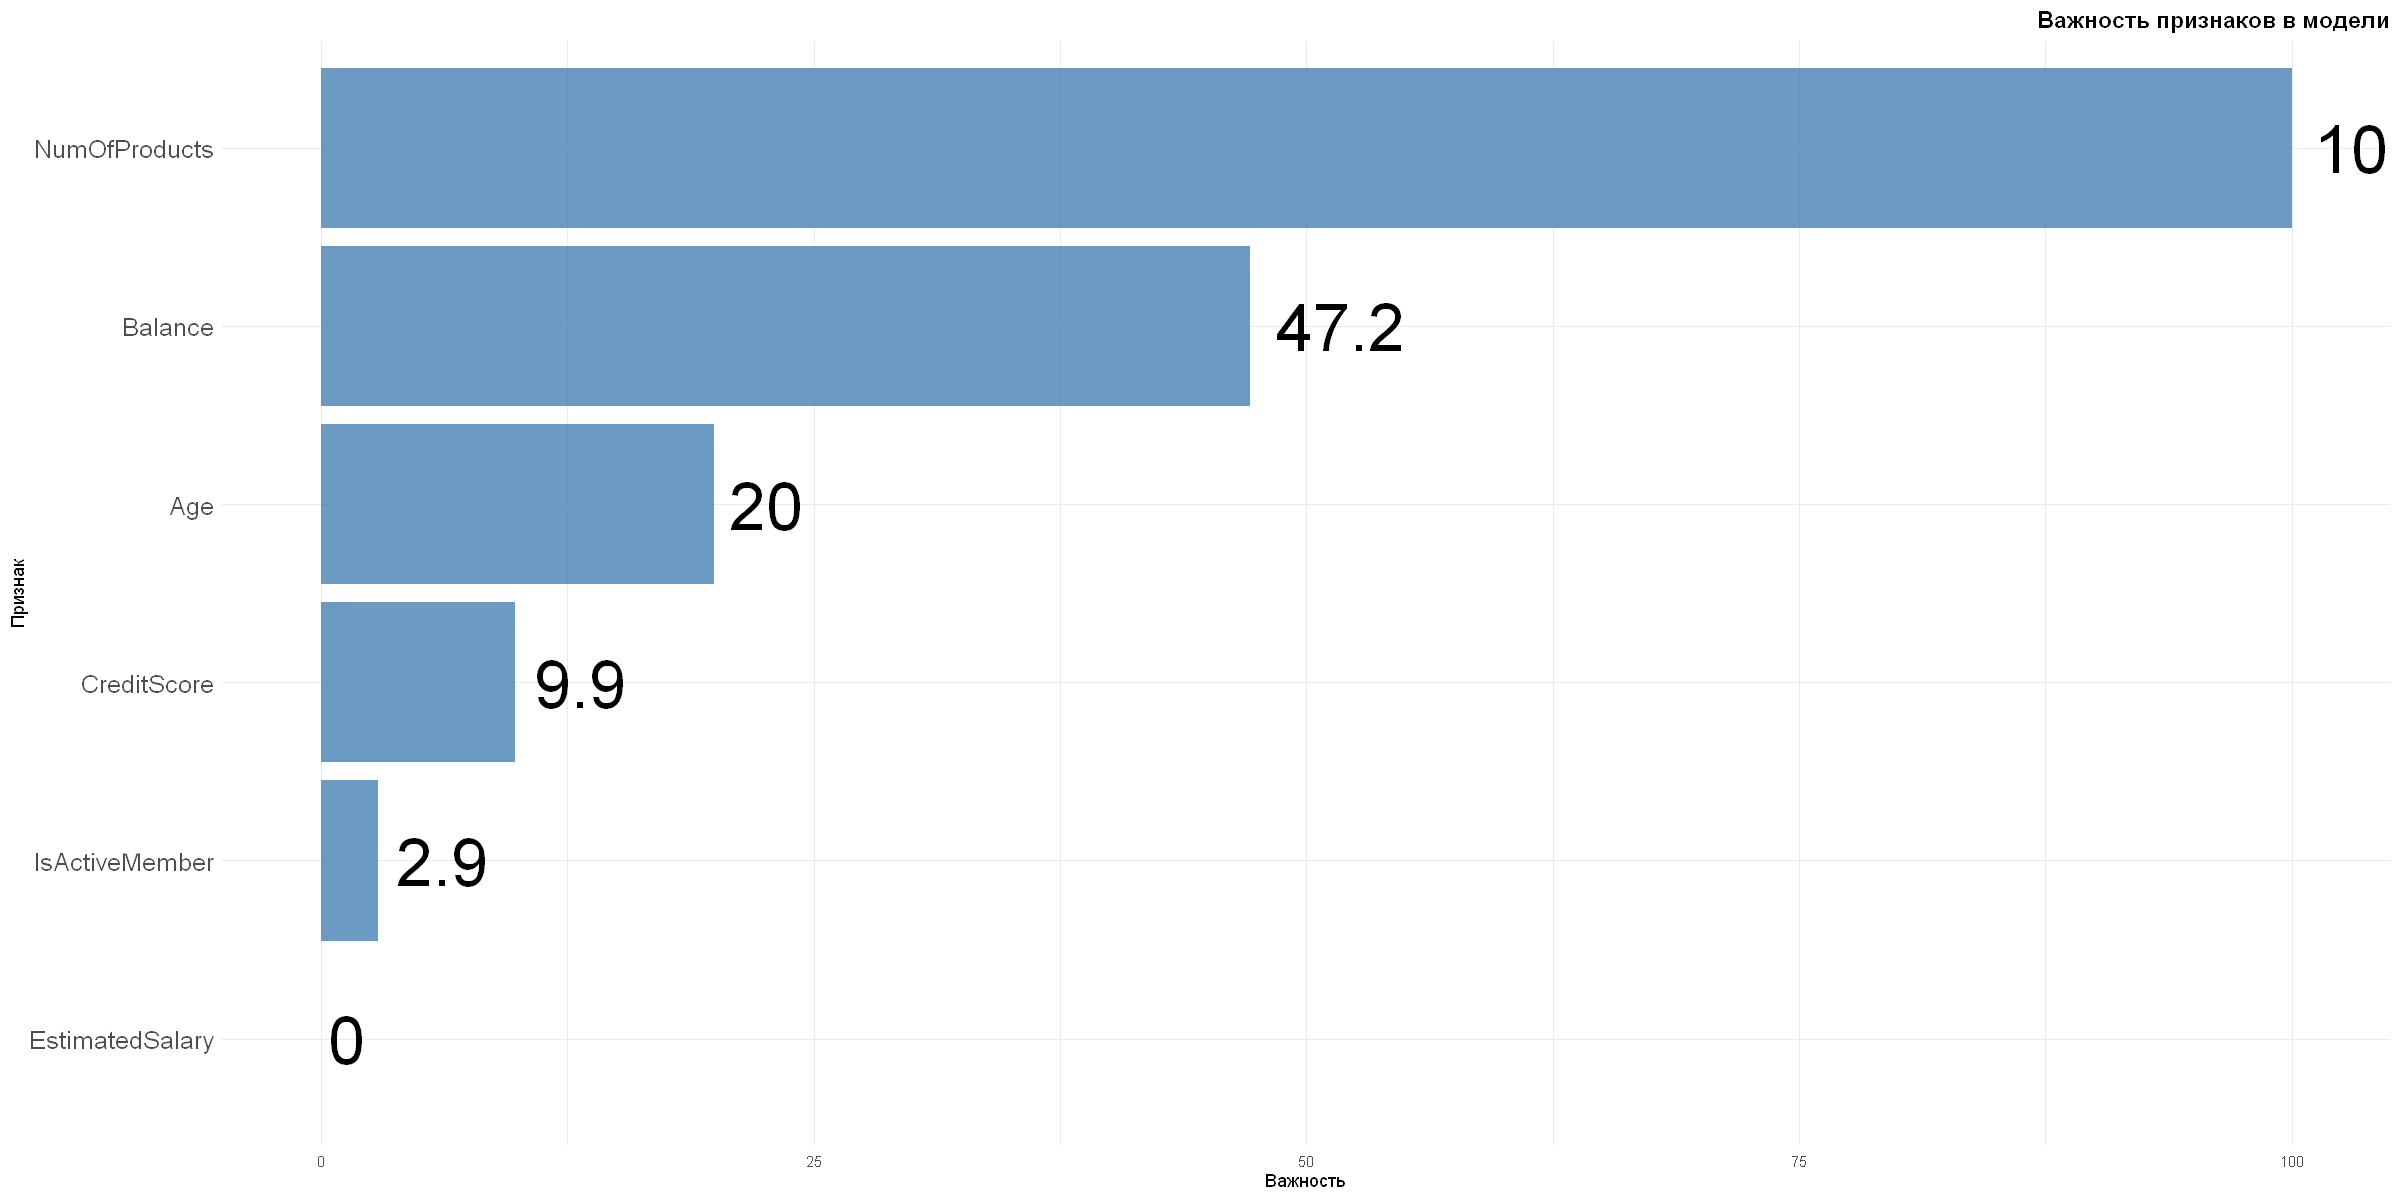

In [ ]:
# ========================================
# ГРАФИК: ВАЖНОСТЬ ПРИЗНАКОВ
# ========================================


ggplot(importance_table, aes(x = reorder(Признак, Важность), y = Важность)) +
    geom_bar(stat = "identity", fill = "steelblue", alpha = 0.8) +
    coord_flip() +
    labs(
        title = "Важность признаков в модели",
        x = "Признак",
        y = "Важность"
    ) +
    theme_minimal() +
    theme(
        plot.title = element_text(hjust = 1, size = 14, face = "bold"),
        axis.text.y = element_text(size = 15)
    ) +
    geom_text(aes(label = round(Важность, 1)), hjust = -0.2, size = 14)

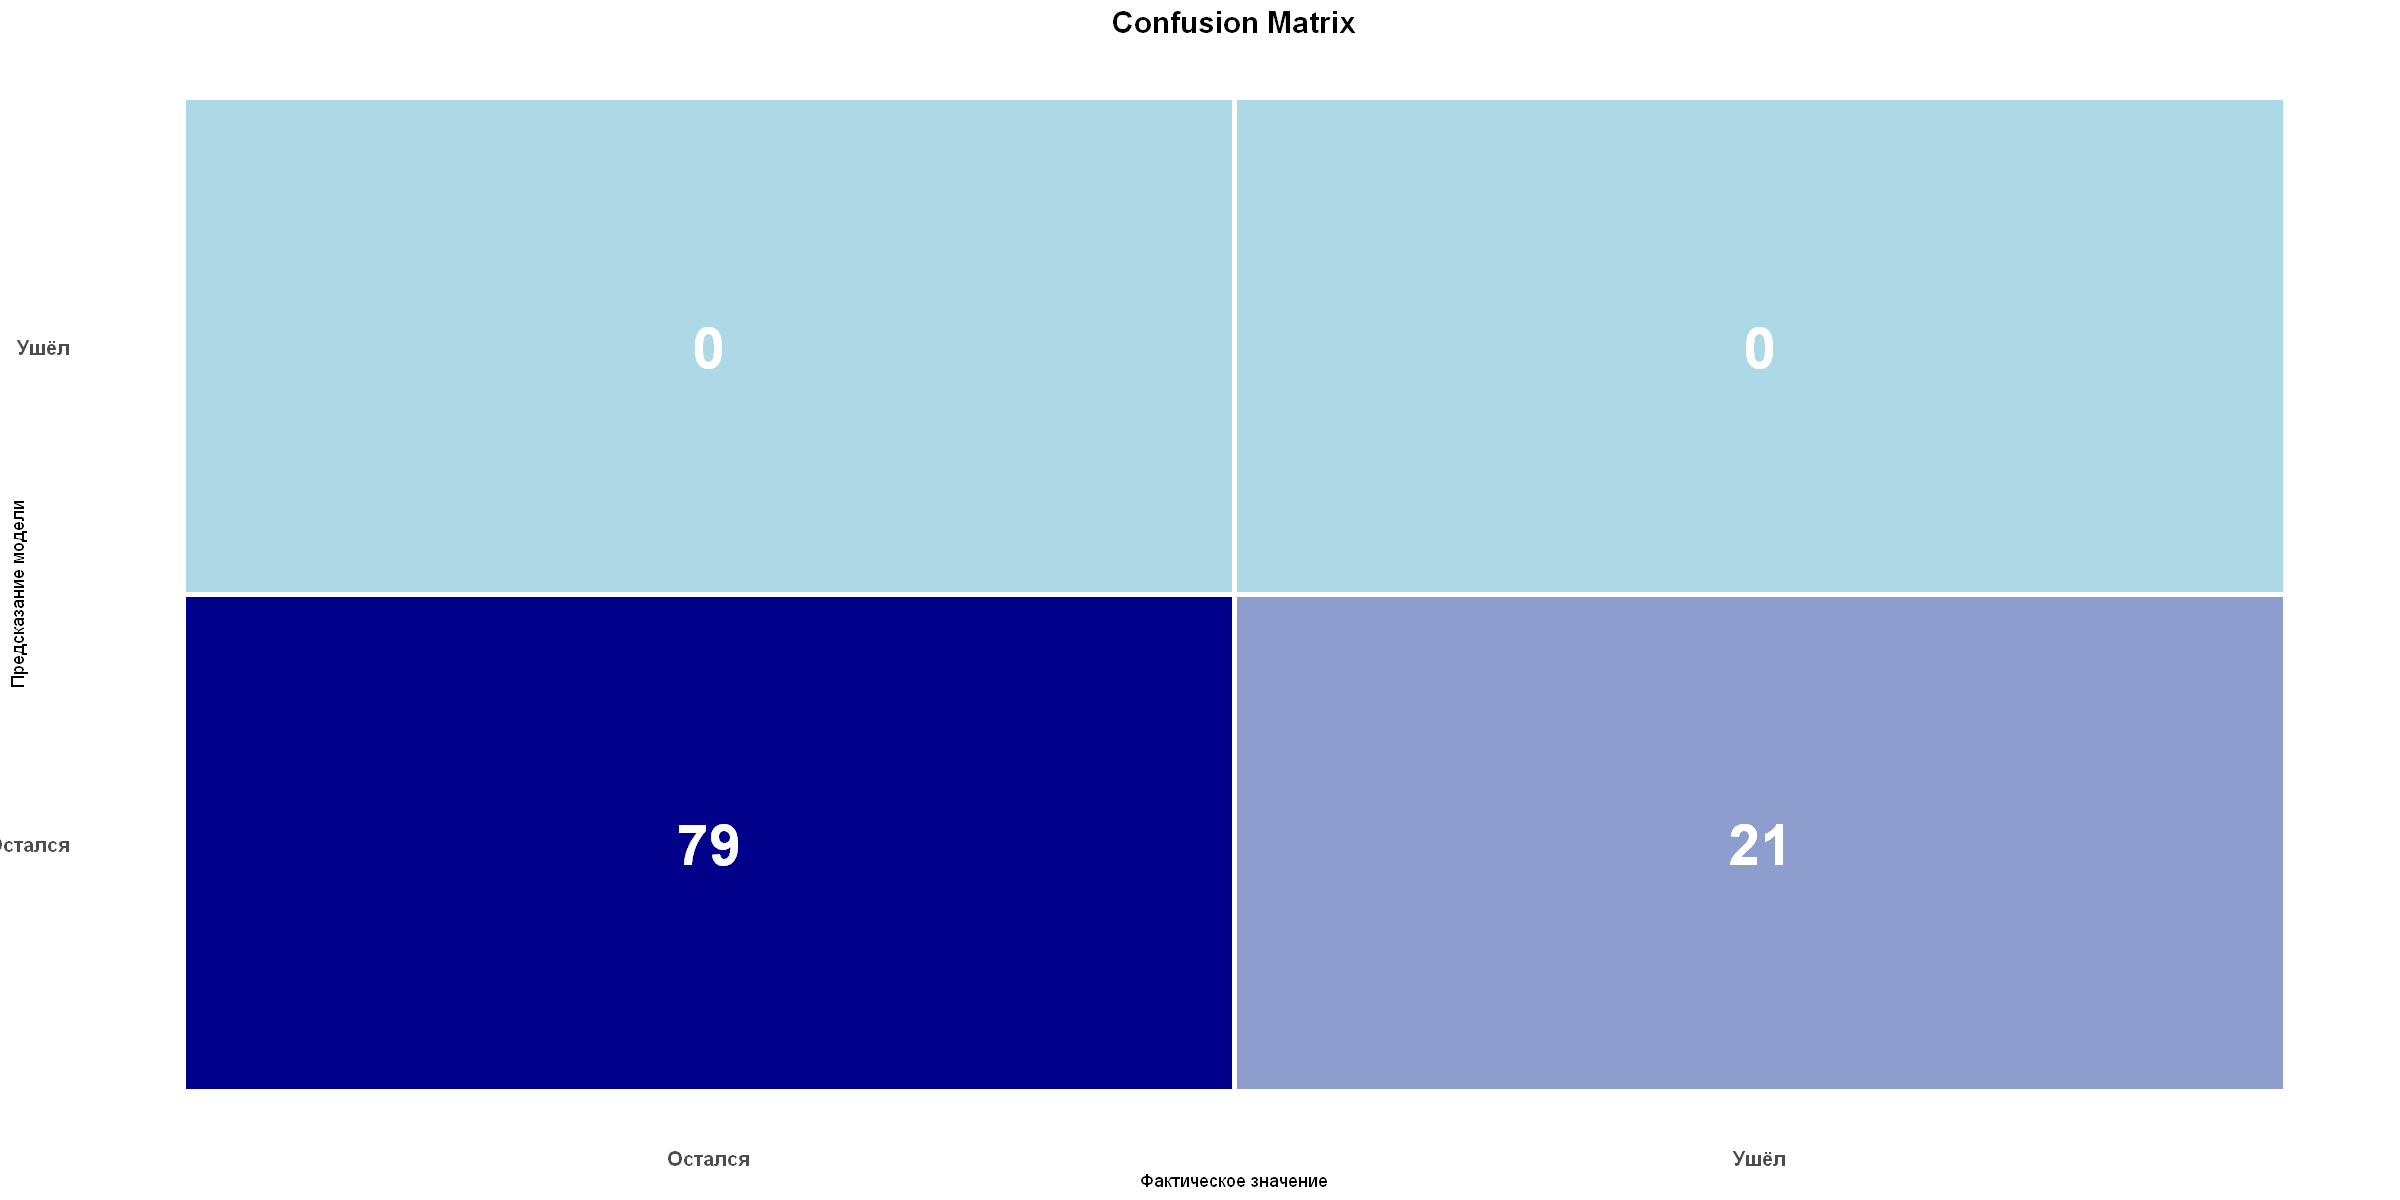

In [ ]:
# ========================================
# ГРАФИК: CONFUSION MATRIX
# ========================================


conf_table <- as.data.frame(table(
    Predicted = predictions_class,
    Actual = test_data$Exited
))

ggplot(conf_table, aes(x = Actual, y = Predicted, fill = Freq)) +
    geom_tile(color = "white", size = 1.5) +
    geom_text(aes(label = Freq), size = 20, fontface = "bold", color = "white") +
    scale_fill_gradient(low = "lightblue", high = "darkblue") +
    scale_x_discrete(labels = c("Остался", "Ушёл")) +
    scale_y_discrete(labels = c("Остался", "Ушёл")) +
    labs(
        title = "Confusion Matrix",
        x = "Фактическое значение",
        y = "Предсказание модели"
    ) +
    theme_minimal() +
    theme(
        plot.title = element_text(hjust = 0.5, size = 18, face = "bold"),
        axis.text = element_text(size = 12, face = "bold"),
        legend.position = "none",
        panel.grid = element_blank()
    )

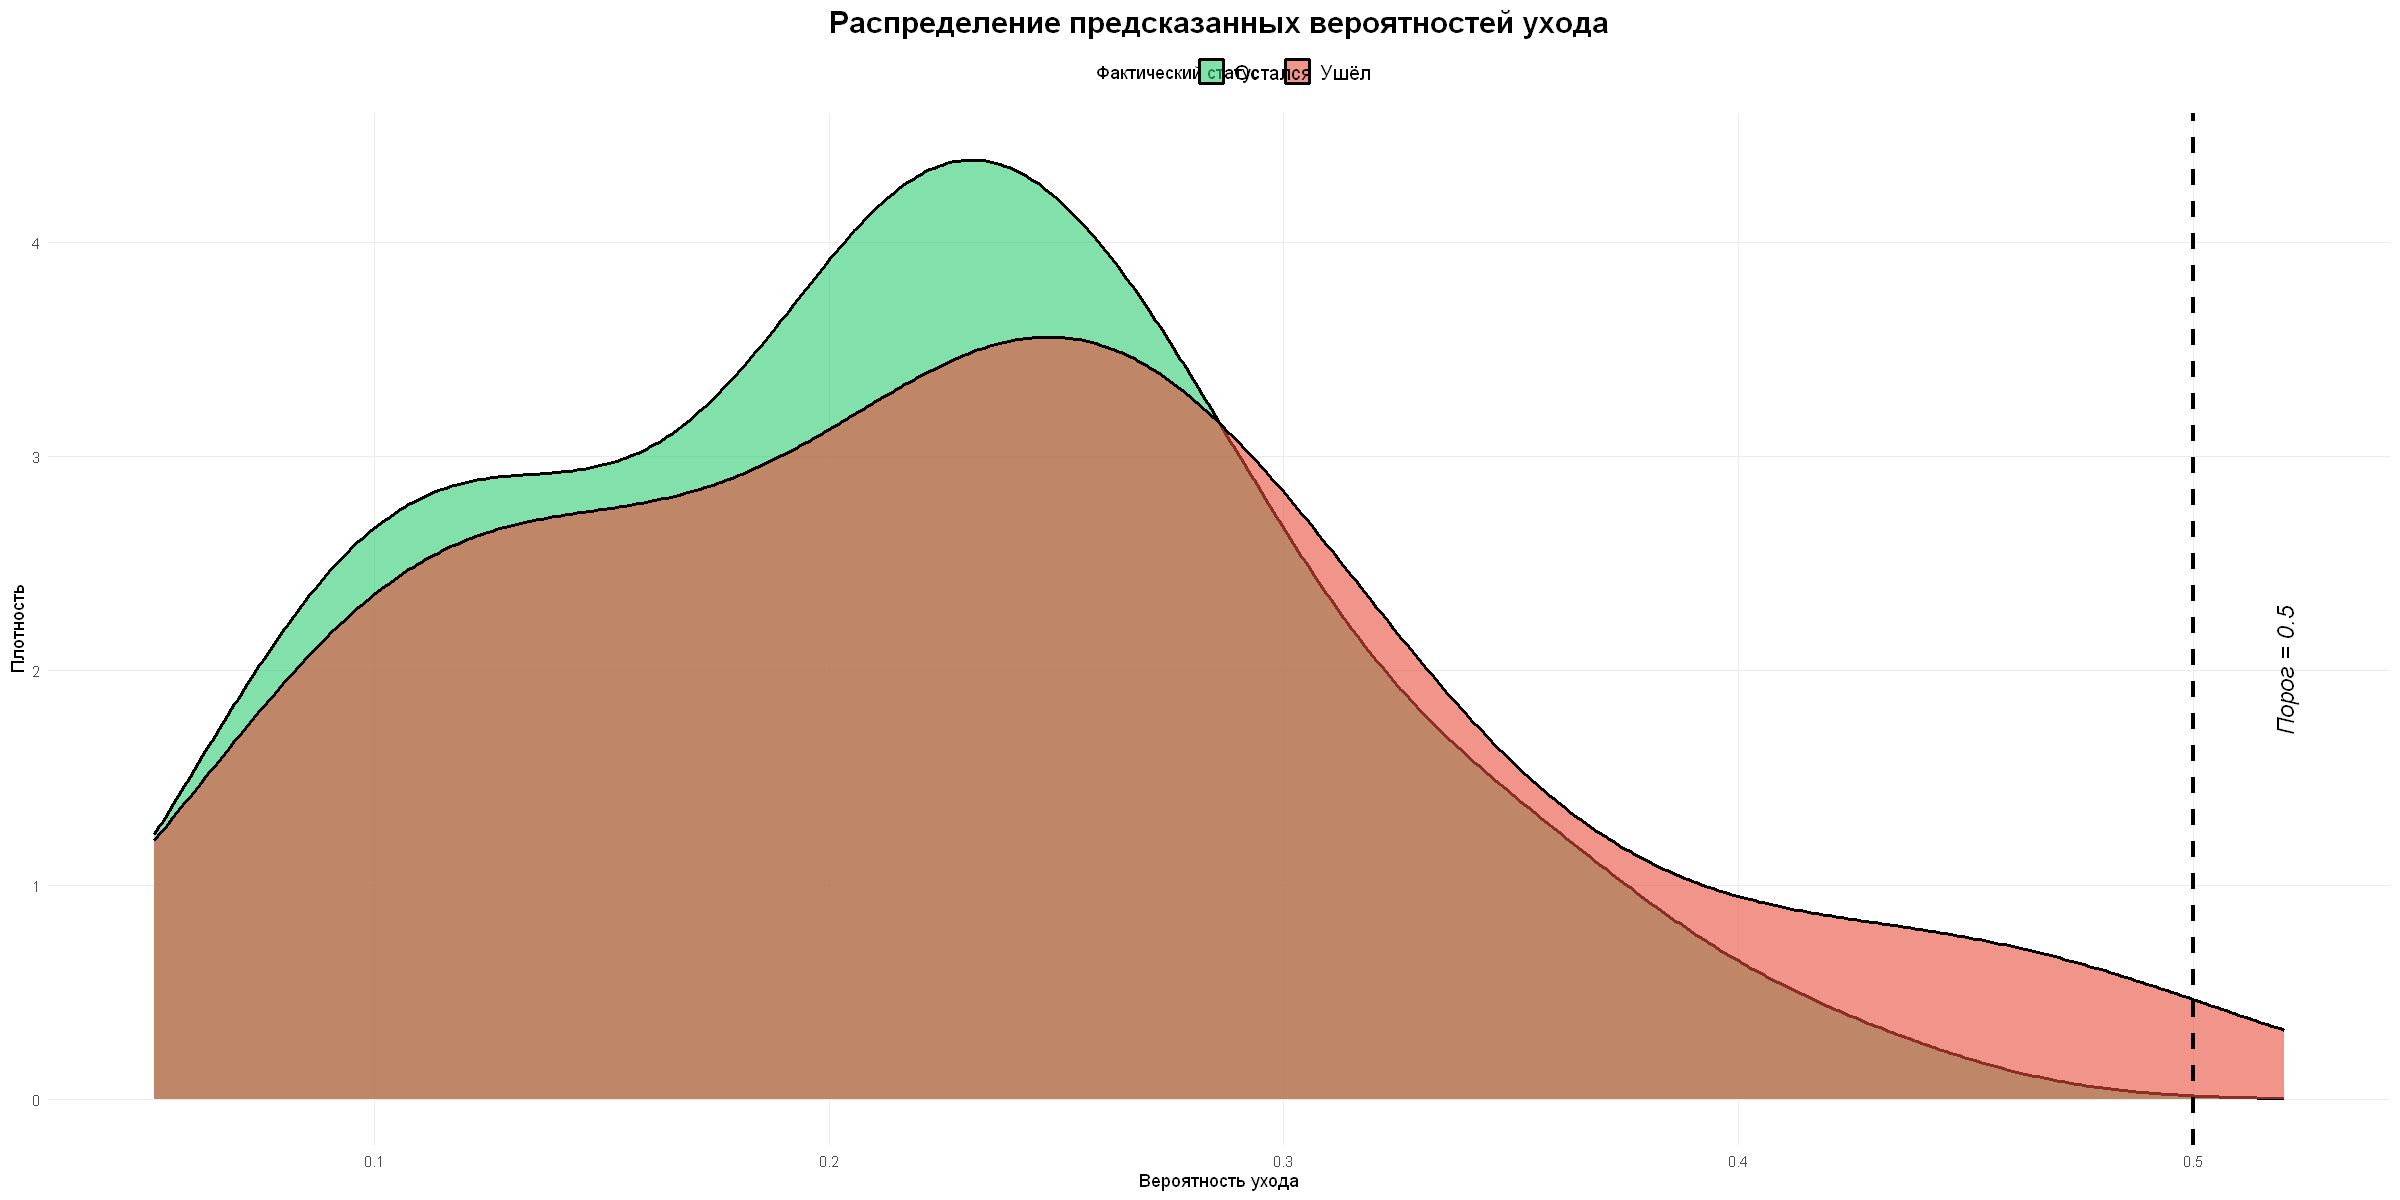

In [ ]:

# Данные для графика
density_data <- data.frame(
    Probability = predictions_prob[, 2],
    Actual = factor(test_data$Exited, labels = c("Остался", "Ушёл"))
)

ggplot(density_data, aes(x = Probability, fill = Actual)) +
    geom_density(alpha = 0.6, size = 1) +
    geom_vline(xintercept = 0.5, linetype = "dashed", color = "black", size = 1.2) +
    scale_fill_manual(values = c("Остался" = "#2ecc71", "Ушёл" = "#e74c3c")) +
    labs(
        title = "Распределение предсказанных вероятностей ухода",
        x = "Вероятность ухода",
        y = "Плотность",
        fill = "Фактический статус"
    ) +
    theme_minimal() +
    theme(
        plot.title = element_text(hjust = 0.5, size = 18, face = "bold"),
        legend.position = "top",
        legend.text = element_text(size = 12),
        panel.grid.minor = element_blank()
    ) +
    annotate("text", x = 0.52, y = 2, label = "Порог = 0.5", 
             angle = 90, size = 5, fontface = "italic")

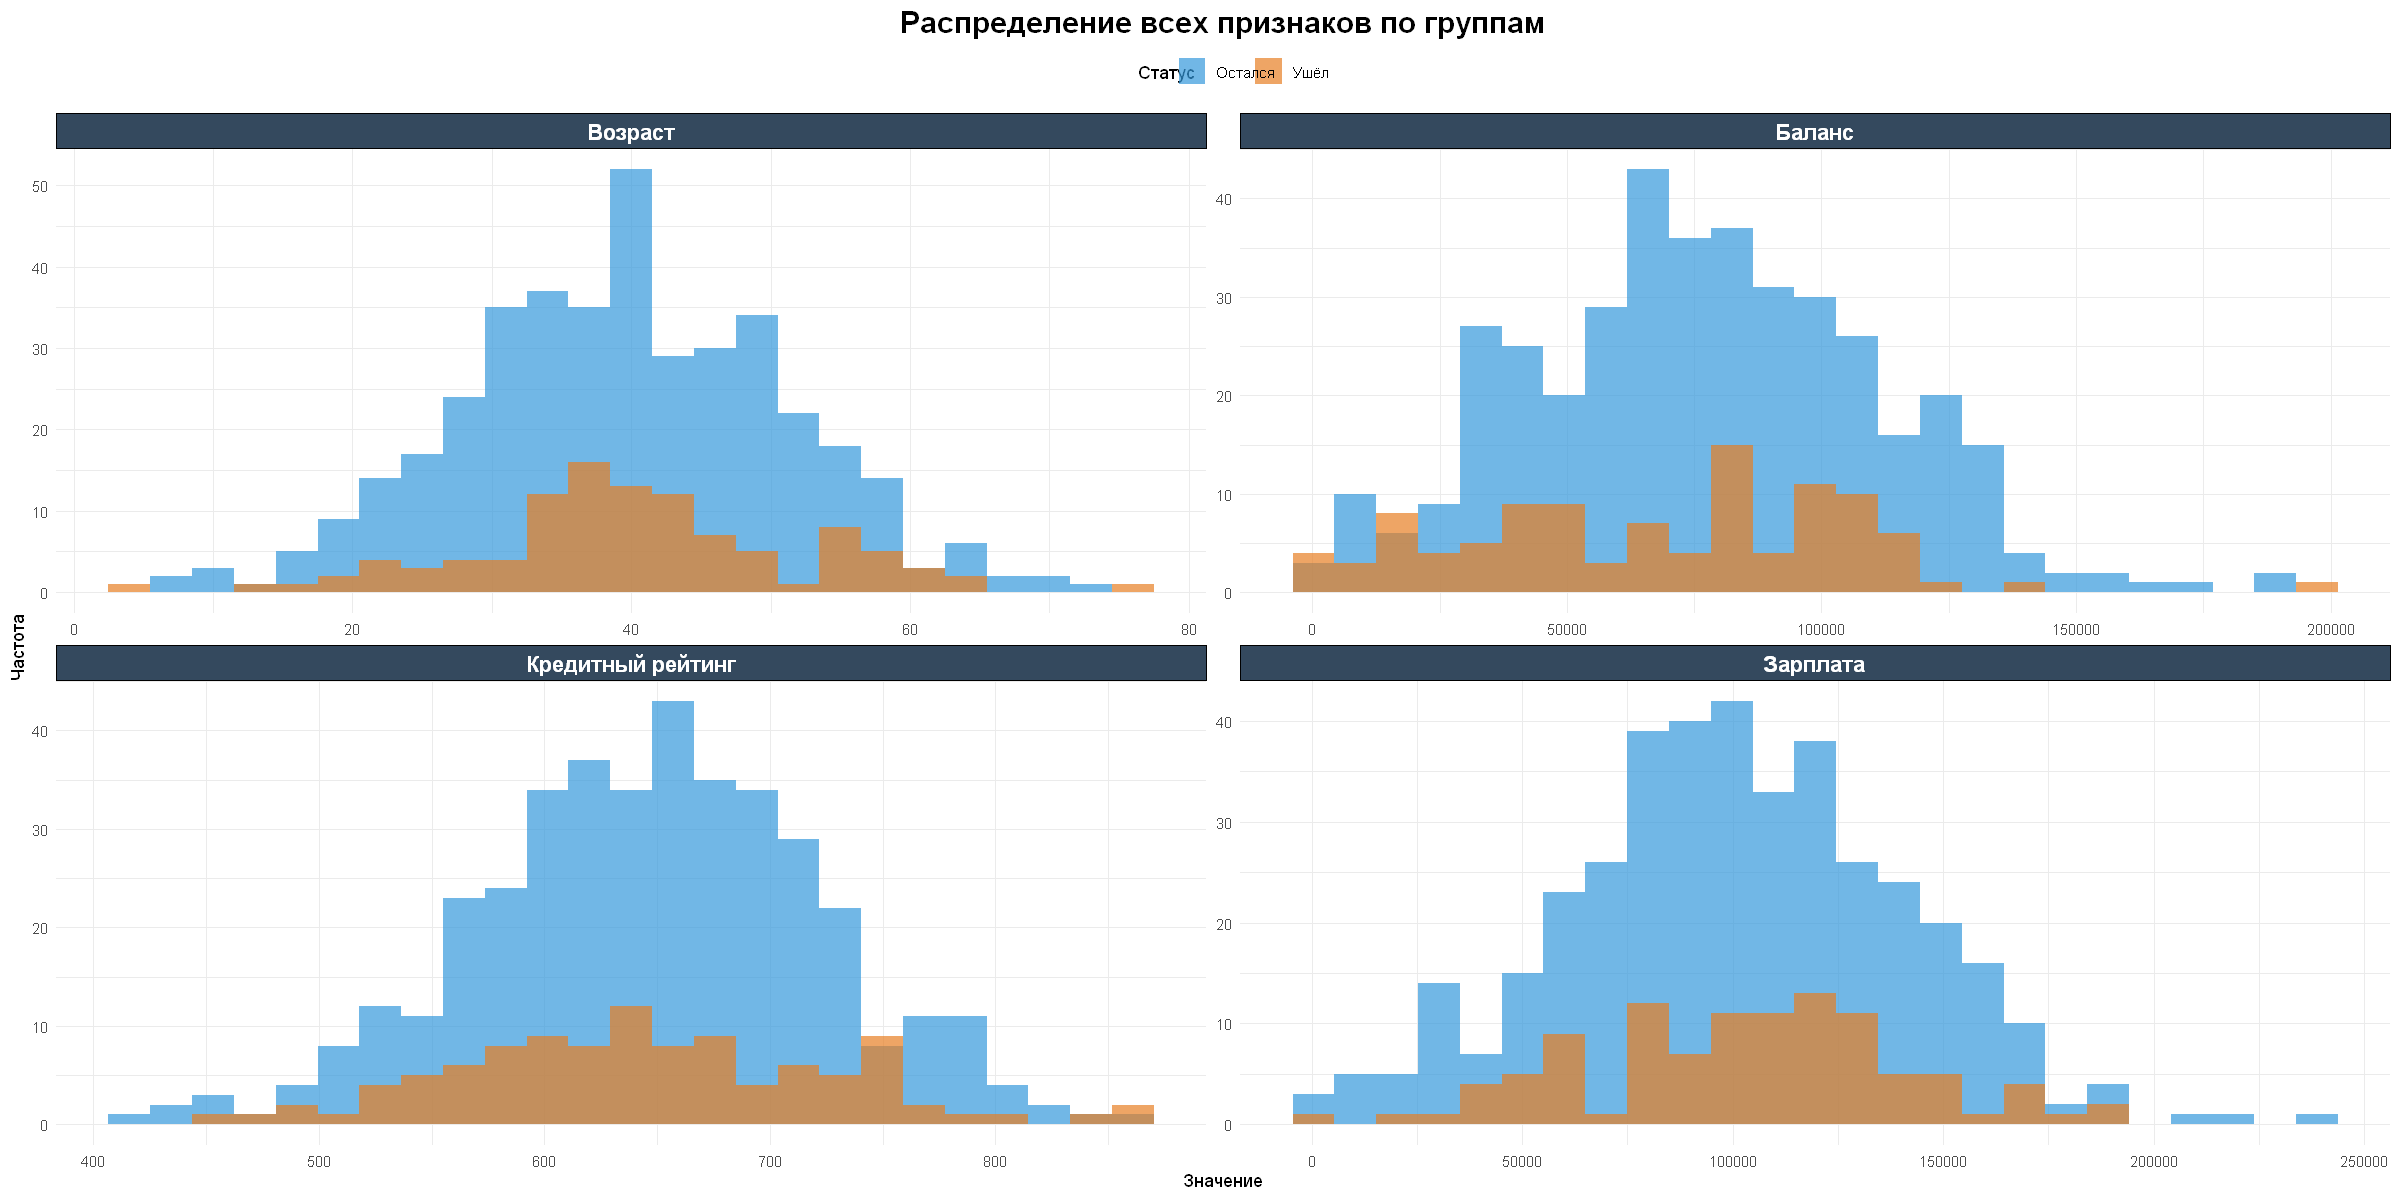

In [ ]:

# Подготовка данных
library(tidyr)
library(dplyr)

facet_data <- db %>%
    select(Age, Balance, CreditScore, EstimatedSalary, Exited) %>%
    pivot_longer(cols = -Exited, names_to = "Variable", values_to = "Value")

facet_data$Exited <- factor(facet_data$Exited, labels = c("Остался", "Ушёл"))

# Красивые имена переменных
facet_data$Variable <- factor(
    facet_data$Variable,
    levels = c("Age", "Balance", "CreditScore", "EstimatedSalary"),
    labels = c("Возраст", "Баланс", "Кредитный рейтинг", "Зарплата")
)

ggplot(facet_data, aes(x = Value, fill = Exited)) +
    geom_histogram(alpha = 0.7, bins = 25, position = "identity") +
    facet_wrap(~Variable, scales = "free", ncol = 2) +
    scale_fill_manual(values = c("Остался" = "#3498db", "Ушёл" = "#e67e22")) +
    labs(
        title = "Распределение всех признаков по группам",
        x = "Значение",
        y = "Частота",
        fill = "Статус"
    ) +
    theme_minimal() +
    theme(
        plot.title = element_text(hjust = 0.5, size = 18, face = "bold"),
        strip.text = element_text(size = 13, face = "bold", color = "white"),
        strip.background = element_rect(fill = "#34495e"),
        legend.position = "top"
    )

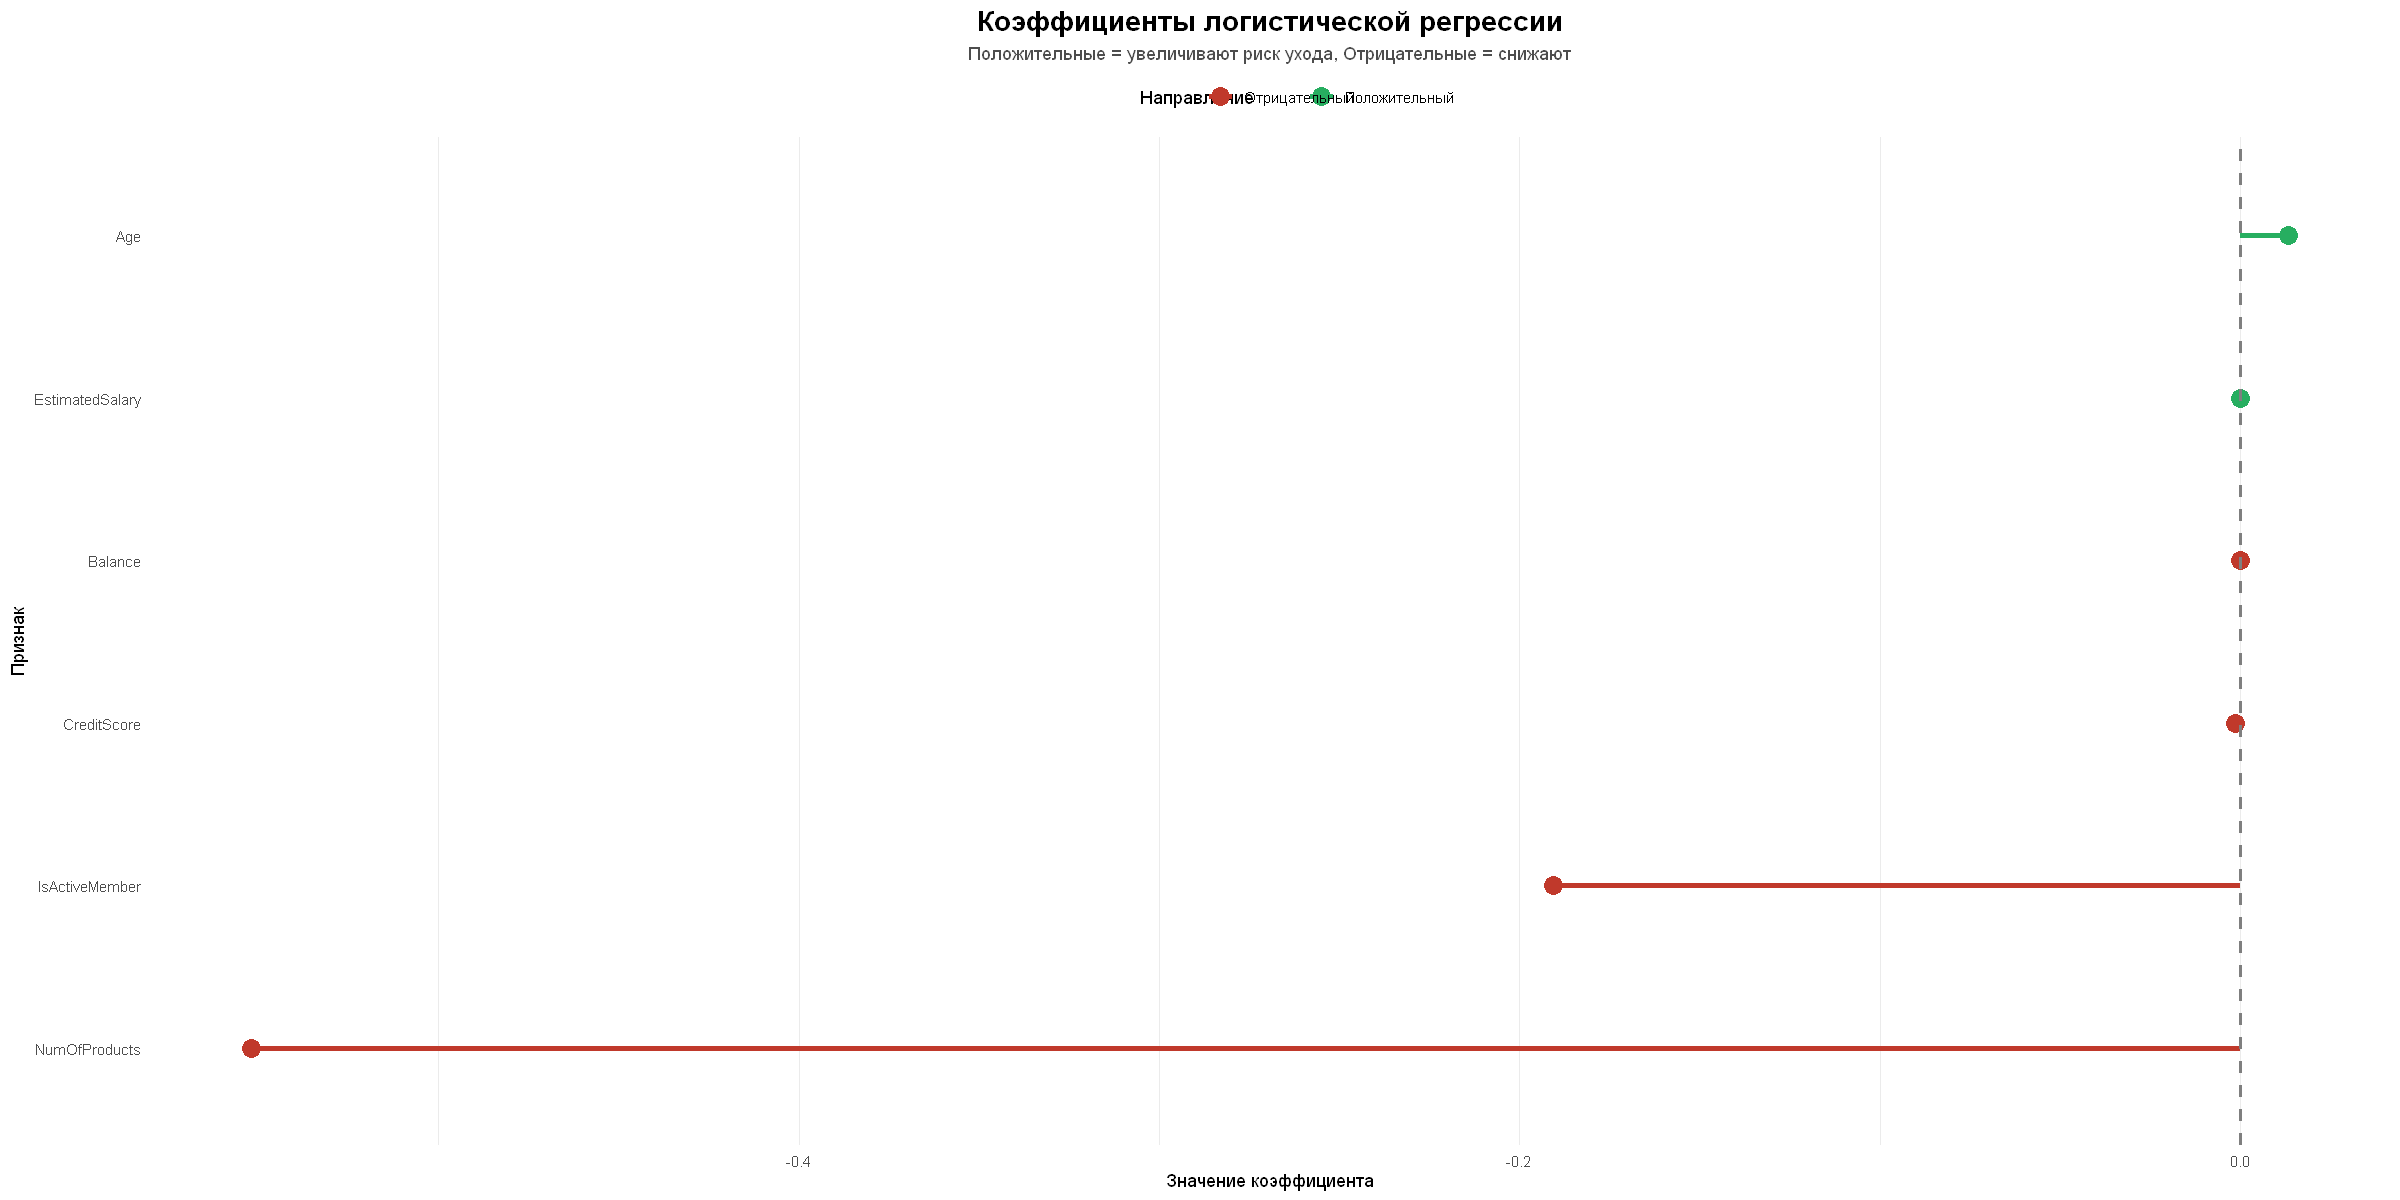

In [ ]:

# Данные коэффициентов (без Intercept)
coef_data <- data.frame(
    Feature = names(coef(model$finalModel))[-1],  # убираем Intercept
    Coefficient = coef(model$finalModel)[-1]
)

coef_data$Color <- ifelse(coef_data$Coefficient > 0, "Положительный", "Отрицательный")
coef_data <- coef_data[order(coef_data$Coefficient), ]

ggplot(coef_data, aes(x = reorder(Feature, Coefficient), y = Coefficient, color = Color)) +
    geom_segment(aes(x = reorder(Feature, Coefficient), 
                     xend = reorder(Feature, Coefficient),
                     y = 0, yend = Coefficient), 
                 size = 1.5) +
    geom_point(size = 5) +
    coord_flip() +
    scale_color_manual(values = c("Положительный" = "#27ae60", "Отрицательный" = "#c0392b")) +
    geom_hline(yintercept = 0, linetype = "dashed", color = "gray50", size = 1) +
    labs(
        title = "Коэффициенты логистической регрессии",
        subtitle = "Положительные = увеличивают риск ухода, Отрицательные = снижают",
        x = "Признак",
        y = "Значение коэффициента",
        color = "Направление"
    ) +
    theme_minimal() +
    theme(
        plot.title = element_text(hjust = 0.5, size = 17, face = "bold"),
        plot.subtitle = element_text(hjust = 0.5, size = 11, color = "gray30"),
        legend.position = "top",
        panel.grid.major.y = element_blank()
    )

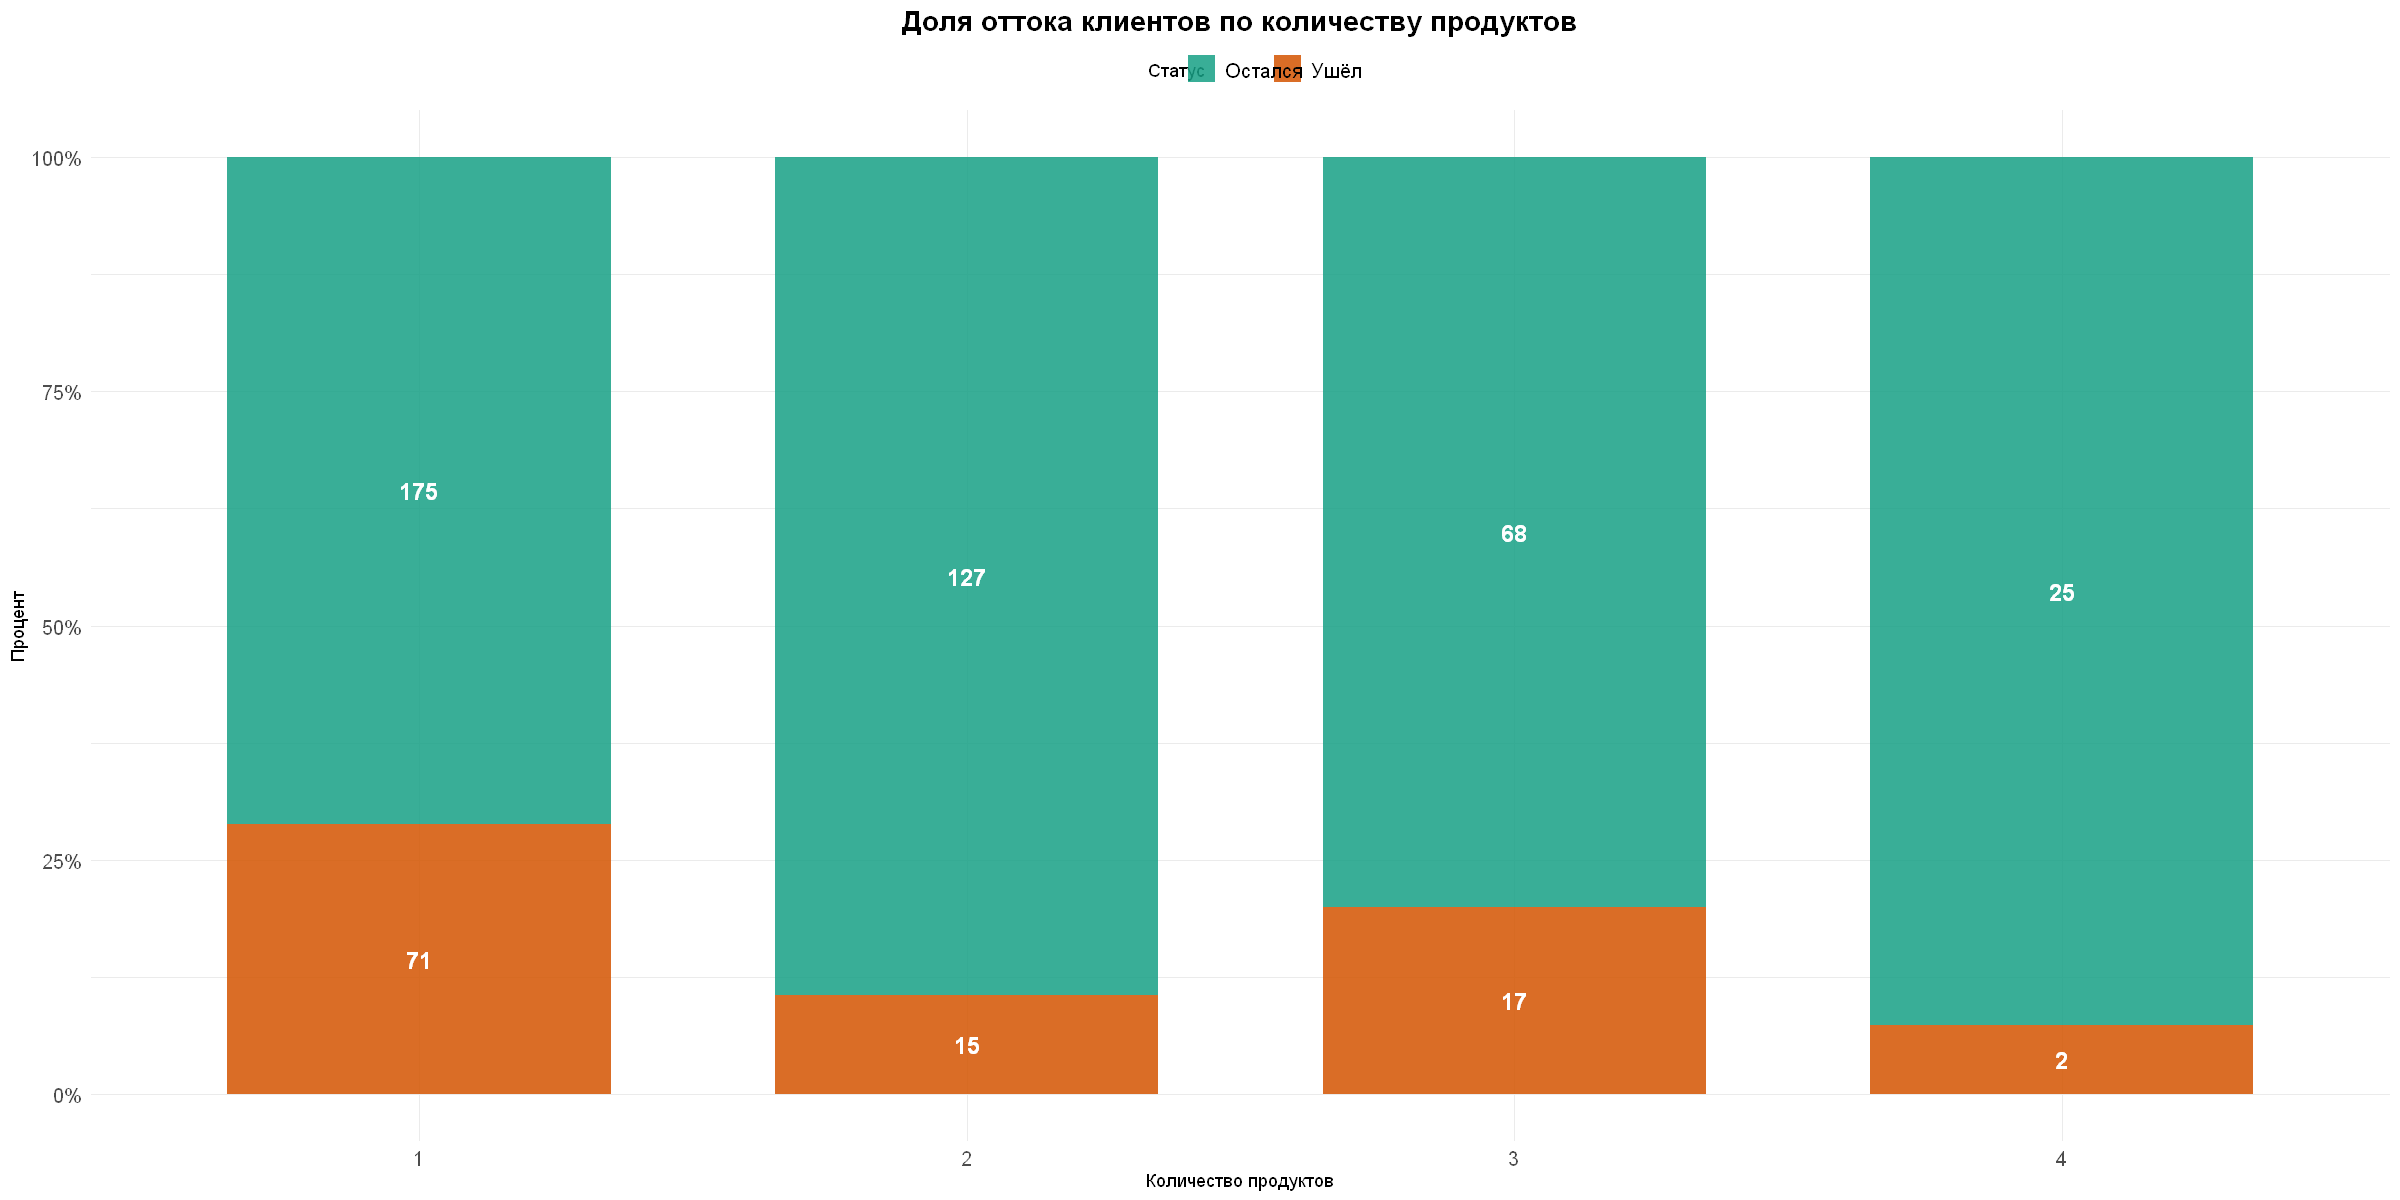

In [ ]:

# Данные для графика
stacked_data <- db %>%
    group_by(NumOfProducts, Exited) %>%
    summarise(Count = n(), .groups = "drop")

stacked_data$Exited <- factor(stacked_data$Exited, labels = c("Остался", "Ушёл"))

ggplot(stacked_data, aes(x = factor(NumOfProducts), y = Count, fill = Exited)) +
    geom_bar(stat = "identity", position = "fill", alpha = 0.85, width = 0.7) +
    geom_text(
        aes(label = Count),
        position = position_fill(vjust = 0.5),
        size = 5,
        fontface = "bold",
        color = "white"
    ) +
    scale_fill_manual(values = c("Остался" = "#16a085", "Ушёл" = "#d35400")) +
    scale_y_continuous(labels = scales::percent) +
    labs(
        title = "Доля оттока клиентов по количеству продуктов",
        x = "Количество продуктов",
        y = "Процент",
        fill = "Статус"
    ) +
    theme_minimal() +
    theme(
        plot.title = element_text(hjust = 0.5, size = 17, face = "bold"),
        axis.text = element_text(size = 12),
        legend.position = "top",
        legend.text = element_text(size = 12)
    )

In [ ]:
# Вычисляем средние и стандартные ошибки
summary_stats <- db %>%
    group_by(Exited) %>%
    summarise(
        Mean_Age = mean(Age),
        SE_Age = sd(Age) / sqrt(n()),
        Mean_Balance = mean(Balance),
        SE_Balance = sd(Balance) / sqrt(n()),
        Mean_Credit = mean(CreditScore),
        SE_Credit = sd(CreditScore) / sqrt(n())
    )

# Преобразуем в long format
summary_long <- summary_stats %>%
    pivot_longer(
        cols = -Exited,
        names_to = c(". value", "Variable"),
        names_pattern = "(Mean|SE)_(.*)"
    )

summary_long$Exited <- factor(summary_long$Exited, labels = c("Остался", "Ушёл"))
summary_long$Variable <- factor(
    summary_long$Variable,
    levels = c("Age", "Balance", "Credit"),
    labels = c("Возраст", "Баланс", "Кредитный рейтинг")
)

ggplot(summary_long, aes(x = Variable, y = Mean, color = Exited, group = Exited)) +
    geom_line(size = 1.2, alpha = 0.6) +
    geom_pointrange(
        aes(ymin = Mean - 1.96 * SE, ymax = Mean + 1.96 * SE),
        size = 1,
        linewidth = 1.5,
        position = position_dodge(width = 0.3)
    ) +
    scale_color_manual(values = c("Остался" = "#2980b9", "Ушёл" = "#c0392b")) +
    labs(
        title = "Средние значения признаков с 95% доверительными интервалами",
        x = "Признак",
        y = "Среднее значение",
        color = "Статус"
    ) +
    theme_minimal() +
    theme(
        plot.title = element_text(hjust = 0.5, size = 16, face = "bold"),
        legend.position = "top",
        panel.grid.major.x = element_blank()
    ) +
    facet_wrap(~ Variable, scales = "free_y", ncol = 3)

ERROR while rich displaying an object: Error in `geom_line()`:
! Problem while computing aesthetics.
ℹ Error occurred in the 1st layer.
Caused by error:
! объект 'Mean' не найден

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .   

Загрузка требуемого пакета: hexbin

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
"нет пакета под названием 'hexbin'"


пакет 'hexbin' успешно распакован, MD5-суммы проверены

Скачанные бинарные пакеты находятся в
	C:\Users\yaeKi\AppData\Local\Temp\Rtmpcfw9Tq\downloaded_packages


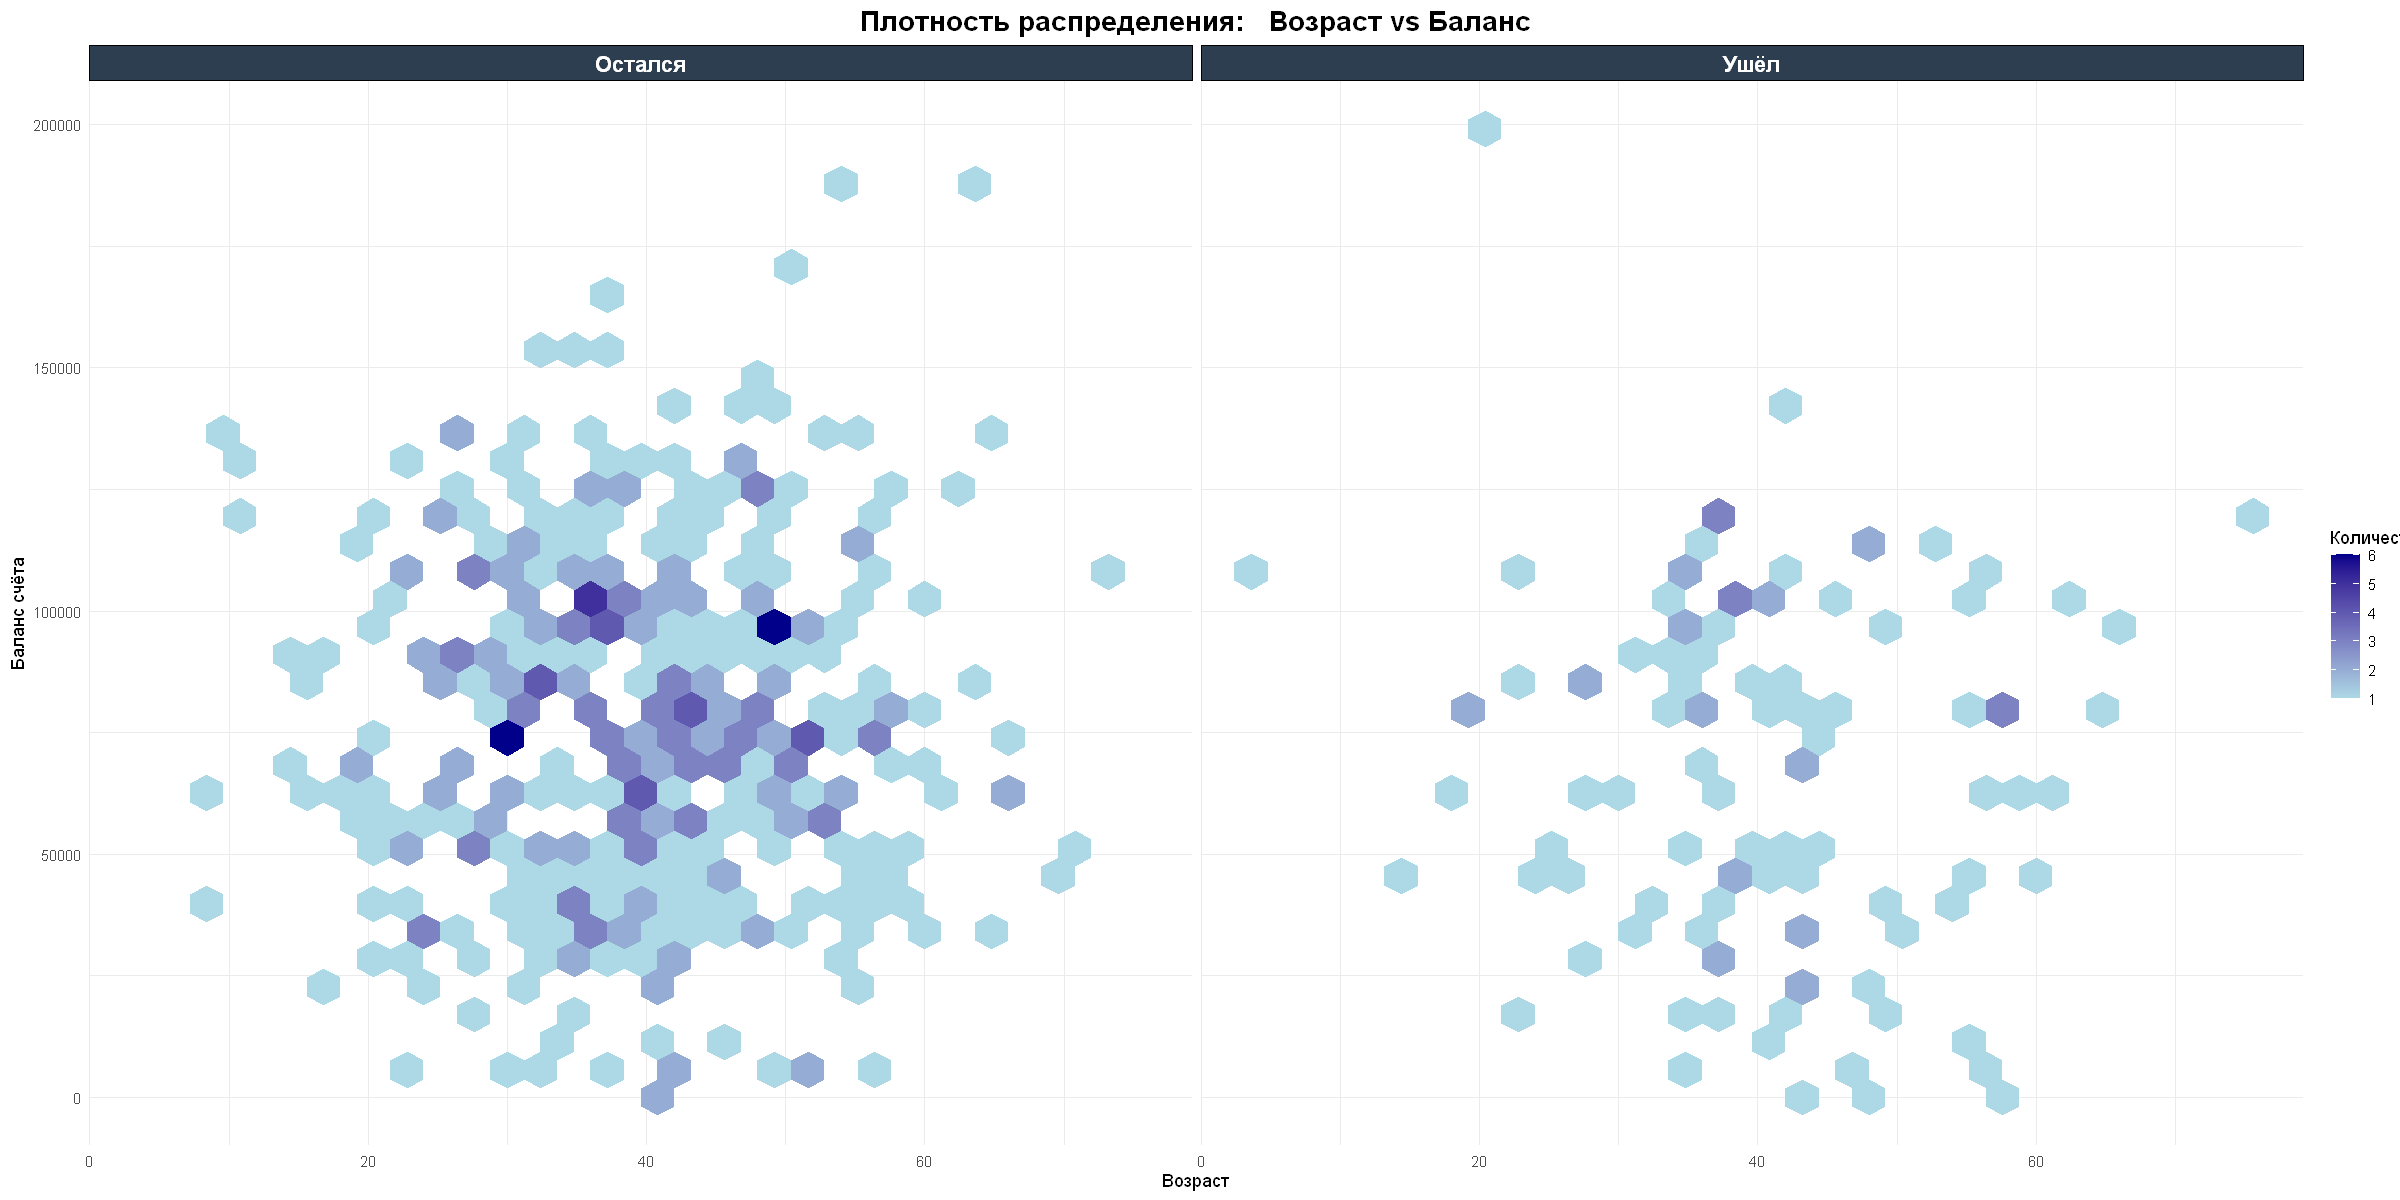

In [ ]:

# Требуется пакет hexbin
if (!require("hexbin")) {
    install.packages("hexbin")
    library(hexbin)
}

ggplot(db, aes(x = Age, y = Balance)) +
    geom_hex(bins = 30) +
    scale_fill_gradient(low = "lightblue", high = "darkblue", name = "Количество") +
    facet_wrap(~ factor(Exited, labels = c("Остался", "Ушёл"))) +
    labs(
        title = "Плотность распределения:   Возраст vs Баланс",
        x = "Возраст",
        y = "Баланс счёта"
    ) +
    theme_minimal() +
    theme(
        plot.title = element_text(hjust = 0.5, size = 17, face = "bold"),
        strip.text = element_text(size = 13, face = "bold", color = "white"),
        strip.background = element_rect(fill = "#2c3e50")
    )

Picking joint bandwidth of 13900



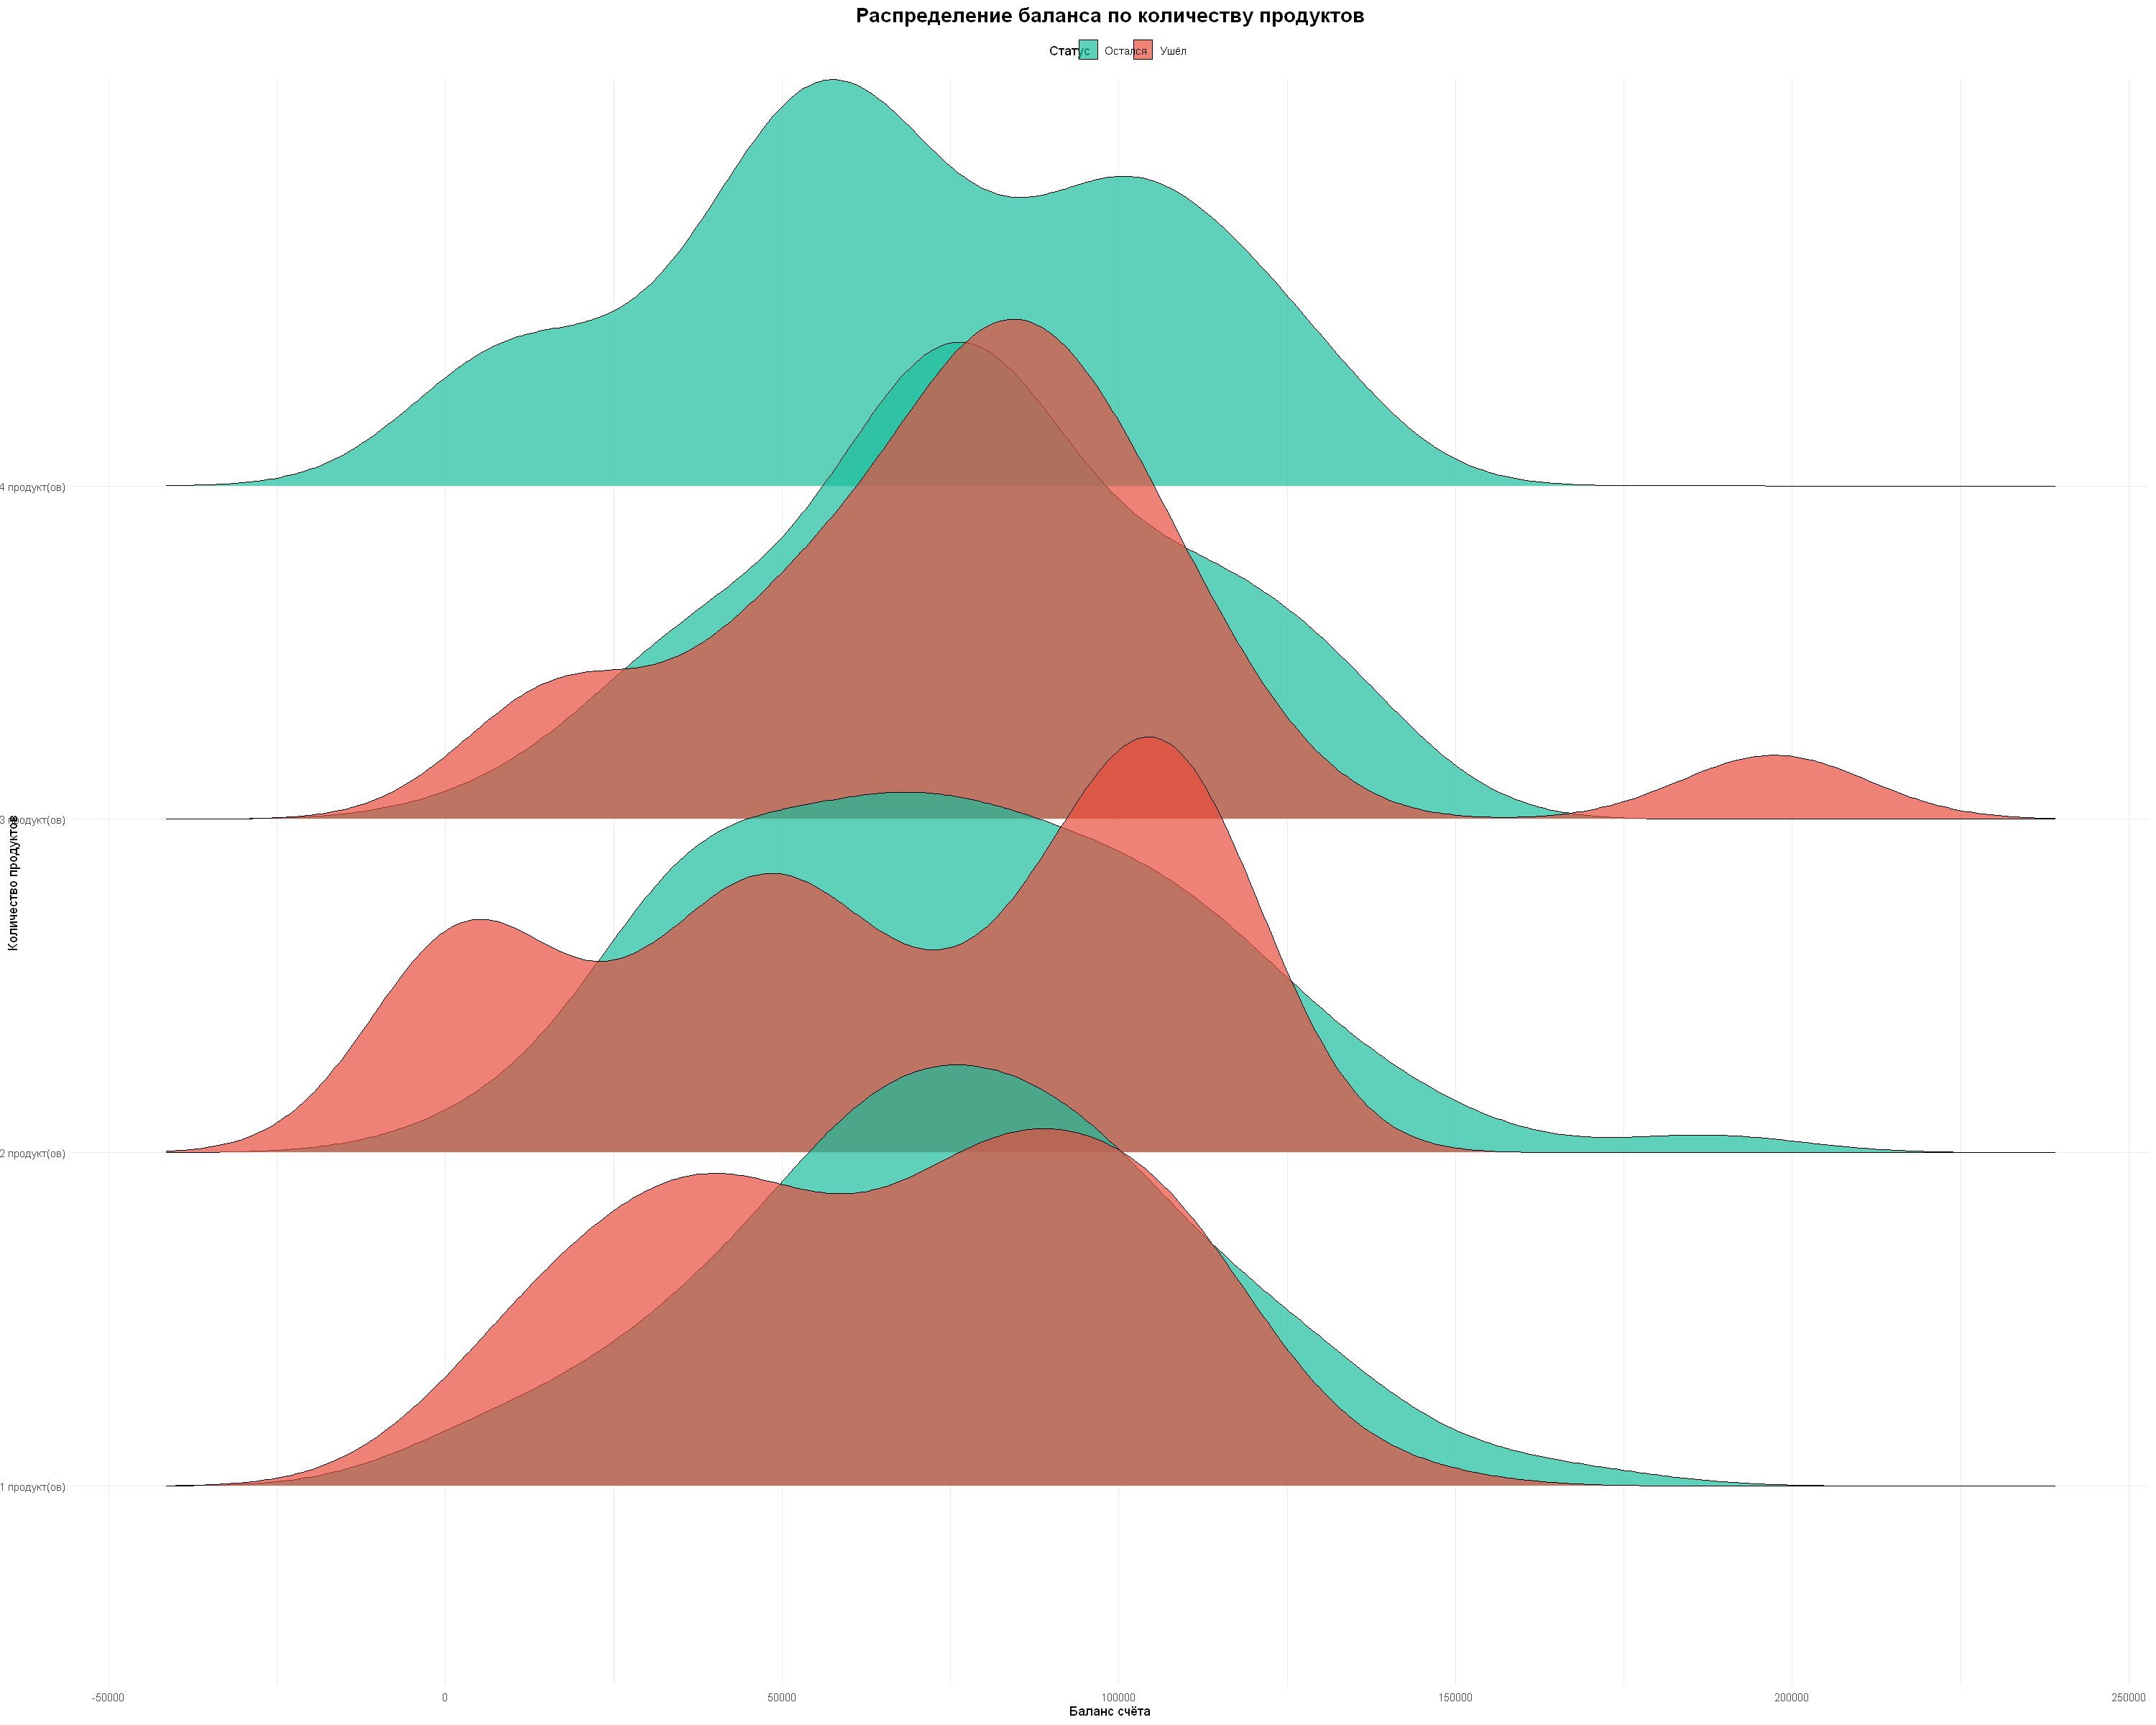

In [ ]:
options(repr.plot.width = 25, repr.plot.height = 20)
# Требуется пакет ggridges
if (!require("ggridges")) {
    install.packages("ggridges")
    library(ggridges)
}

ridge_data <- db
ridge_data$Products_Group <- paste(ridge_data$NumOfProducts, "продукт(ов)")
ridge_data$Exited_Label <- factor(ridge_data$Exited, labels = c("Остался", "Ушёл"))

ggplot(ridge_data, aes(x = Balance, y = Products_Group, fill = Exited_Label)) +
    geom_density_ridges(alpha = 0.7, scale = 1.5) +
    scale_fill_manual(values = c("Остался" = "#1abc9c", "Ушёл" = "#e74c3c")) +
    labs(
        title = "Распределение баланса по количеству продуктов",
        x = "Баланс счёта",
        y = "Количество продуктов",
        fill = "Статус"
    ) +
    theme_minimal() +
    theme(
        plot.title = element_text(hjust = 0.5, size = 17, face = "bold"),
        legend.position = "top"
    )

$add.smooth
[1] TRUE

$ambiguousMethodSelection
function (cond) 
NULL
<environment: R_EmptyEnv>

$browserNLdisabled
[1] FALSE

$callr.condition_handler_cli_message
function (msg) 
{
    custom_handler <- getOption("cli.default_handler")
    if (is.function(custom_handler)) {
        custom_handler(msg)
    }
    else {
        cli_server_default(msg)
    }
}
<bytecode: 0x0000016a9df7c930>
<environment: namespace:cli>

$catch.script.errors
[1] FALSE

$CBoundsCheck
[1] FALSE

$check.bounds
[1] FALSE

$citation.bibtex.max
[1] 1

$continue
[1] "+ "

$contrasts
        unordered           ordered 
"contr.treatment"      "contr.poly" 

$crayon.enabled
[1] TRUE

$datatable.alloccol
[1] 1024

$datatable.allow.cartesian
[1] FALSE

$datatable.auto.index
[1] TRUE

$datatable.dfdispatchwarn
[1] TRUE

$datatable.optimize
[1] Inf

$datatable.print.class
[1] TRUE

$datatable.print.colnames
[1] "auto"

$datatable.print.keys
[1] TRUE

$datatable.print.nrows
[1] 100

$datatable.print.rownames
[1] TRUE



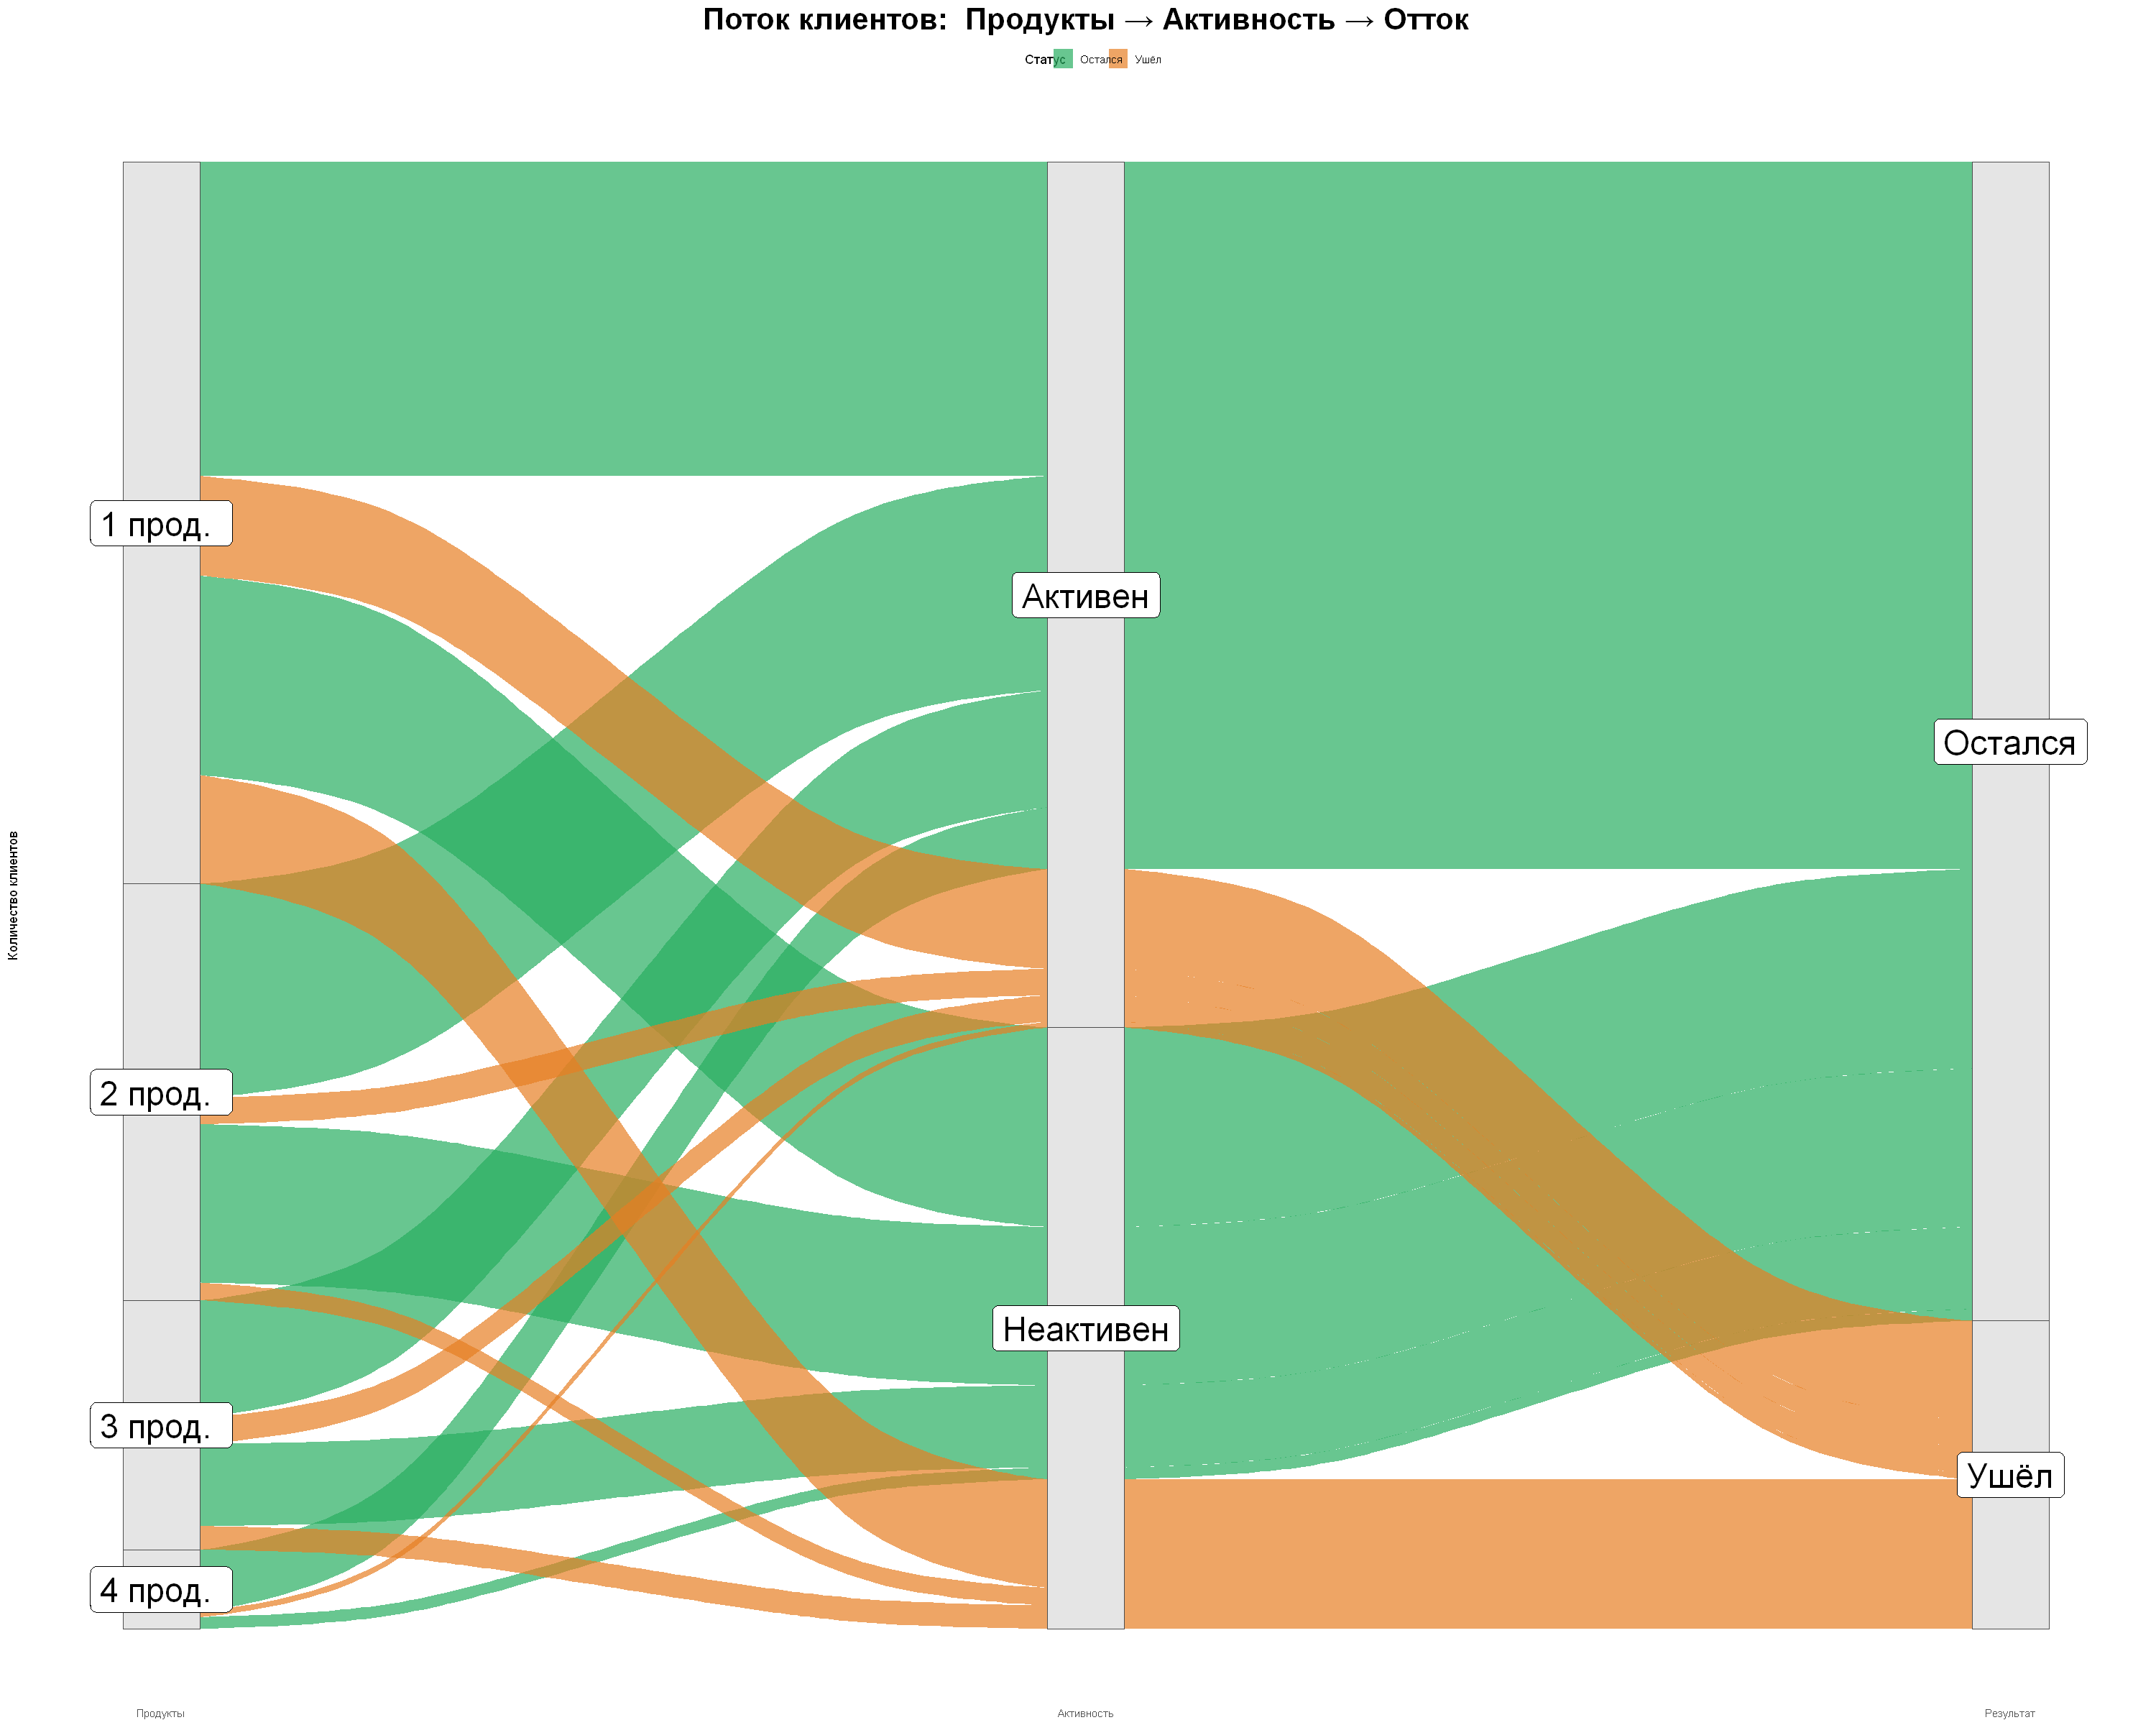

In [ ]:
options()# Требуется пакет ggalluvial
if (!require("ggalluvial")) {
    install.packages("ggalluvial")
    library(ggalluvial)
}

# Подготовка данных
alluvial_data <- db %>%
    mutate(
        Products = paste(NumOfProducts, "прод. "),
        Active = ifelse(IsActiveMember == 1, "Активен", "Неактивен"),
        Status = ifelse(Exited == 1, "Ушёл", "Остался")
    ) %>%
    group_by(Products, Active, Status) %>%
    summarise(Freq = n(), .groups = "drop")

ggplot(alluvial_data,
       aes(axis1 = Products, axis2 = Active, axis3 = Status, y = Freq)) +
    geom_alluvium(aes(fill = Status), width = 1/12, alpha = 0.7) +
    geom_stratum(width = 1/12, fill = "gray90", color = "gray30") +
    geom_label(stat = "stratum", aes(label = after_stat(stratum)), size = 10) +
    scale_x_discrete(limits = c("Продукты", "Активность", "Результат"), expand = c(.05,.05)) +
    scale_fill_manual(values = c("Остался" = "#27ae60", "Ушёл" = "#e67e22")) +
    labs(
        title = "Поток клиентов:  Продукты → Активность → Отток",
        y = "Количество клиентов",
        fill = "Статус"
    ) +
    theme_minimal() +
    theme(
        plot.title = element_text(hjust = 0.5, size = 25, face = "bold"),
        legend.position = "top",
        panel.grid = element_blank(),
        axis.text.y = element_blank()
    )

In [ ]:
# Требуется пакет waffle
if (!require("waffle")) {
    install.packages("waffle")
    library(waffle)
}

# Данные
waffle_data <- c(
    `Остался (79%)` = round(sum(db$Exited == 0) / 5),
    `Ушёл (21%)` = round(sum(db$Exited == 1) / 5)
)

waffle(
    waffle_data,
    rows = 10,
    size = 1,
    colors = c("#2ecc71", "#e74c3c"),
    title = "Распределение клиентов по статусу",
    xlab = "1 квадрат = 5 клиентов"
) +
    theme(
        plot.title = element_text(hjust = 0.5, size = 17, face = "bold"),
        legend.position = "bottom",
        legend.text = element_text(size = 12)
    )

Загрузка требуемого пакета: waffle

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
"нет пакета под названием 'waffle'"


Warning message:
"пакет ''waffle'' недоступен (for this version of R

Другая версия этого пакета может быть доступна для Вашей версии R из других источников,
см. возможные варианты на
https://cran.r-project.org/doc/manuals/r-patched/R-admin.html#Installing-packages)"


ERROR: Error in library(waffle): нет пакета под названием 'waffle'


In [ ]:
# Создаём "дождевое облако"
raincloud_data <- db
raincloud_data$Exited_Label <- factor(raincloud_data$Exited, labels = c("Остался", "Ушёл"))

ggplot(raincloud_data, aes(x = Exited_Label, y = Balance, fill = Exited_Label)) +
    # Половинка violin
    geom_violin(alpha = 0.6, trim = FALSE, position = position_nudge(x = 0.2)) +
    # Boxplot
    geom_boxplot(width = 0.15, alpha = 0.7, outlier.shape = NA, 
                 position = position_nudge(x = -0.1)) +
    # Точки
    geom_jitter(width = 0.05, alpha = 0.3, size = 1.5, 
                position = position_nudge(x = -0.3)) +
    scale_fill_manual(values = c("Остался" = "#3498db", "Ушёл" = "#e67e22")) +
    labs(
        title = "Raincloud Plot:   Распределение баланса",
        subtitle = "Комбинация violin plot, boxplot и scatter",
        x = "Статус клиента",
        y = "Баланс счёта",
        fill = "Статус"
    ) +
    theme_minimal() +
    theme(
        plot.title = element_text(hjust = 0.5, size = 17, face = "bold"),
        plot.subtitle = element_text(hjust = 0.5, size = 11, color = "gray40"),
        legend.position = "none"
    ) +
    coord_flip()

ERROR: [1m[33mError[39m in `geom_jitter()`:[22m
[1m[22m[33m![39m Both `position` and `width`/`height` were supplied.
[36mℹ[39m Choose a single approach to alter the position.


In [ ]:
# Требуется пакет plotly
if (!require("plotly")) {
    install.packages("plotly")
    library(plotly)
}

# Создаём ggplot
p <- ggplot(db, aes(
    x = Age, y = Balance, color = factor(Exited),
    text = paste(
        "Возраст:", Age,
        "<br>Баланс:", Balance,
        "<br>Продуктов:", NumOfProducts
    )
)) +
    geom_point(alpha = 0.6, size = 3) +
    scale_color_manual(
        values = c("0" = "#2ecc71", "1" = "#e74c3c"),
        labels = c("Остался", "Ушёл")
    ) +
    labs(
        title = "Интерактивный график: Возраст vs Баланс",
        x = "Возраст",
        y = "Баланс",
        color = "Статус"
    ) +
    theme_minimal()

# Делаем интерактивным
ggplotly(p, tooltip = "text")

Загрузка требуемого пакета: plotly

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
"нет пакета под названием 'plotly'"
устанавливаю также зависимости 'fs', 'rappdirs', 'sys', 'cachem', 'memoise', 'sass', 'askpass', 'highr', 'xfun', 'bslib', 'fontawesome', 'jquerylib', 'tinytex', 'curl', 'mime', 'openssl', 'knitr', 'rmarkdown', 'yaml', 'later', 'otel', 'httr', 'htmlwidgets', 'crosstalk', 'promises'





  В наличии есть бинарные версии, но исходники новее:
         binary source needs_compilation
rappdirs  0.3.3  0.3.4              TRUE
xfun       0.55   0.56              TRUE

  Binaries will be installed


Warning message in download.file(urls, destfiles, "libcurl", mode = "wb", ...):
"URL 'https://cran.r-project.org/bin/windows/contrib/4.5/sass_0.4.10.zip': Достигнуто ограничение по времени в 60 с"
Warning message in download.file(urls, destfiles, "libcurl", mode = "wb", ...):
"URL 'https://cran.r-project.org/bin/windows/contrib/4.5/bslib_0.9.0.zip': Достигнуто ограничение по времени в 60 с"
Warning message in download.file(urls, destfiles, "libcurl", mode = "wb", ...):
"URL 'https://cran.r-project.org/bin/windows/contrib/4.5/curl_7.0.0.zip': Достигнуто ограничение по времени в 60 с"
Warning message in download.file(urls, destfiles, "libcurl", mode = "wb", ...):
"URL 'https://cran.r-project.org/bin/windows/contrib/4.5/htmlwidgets_1.6.4.zip': Достигнуто ограничение по времени в 60 с"
Warning message in download.file(urls, destfiles, "libcurl", mode = "wb", ...):
"URL 'https://cran.r-project.org/bin/windows/contrib/4.5/openssl_2.3.4.zip': Достигнуто ограничение по времени в 60 с"
Warning 

пакет 'fs' успешно распакован, MD5-суммы проверены
пакет 'rappdirs' успешно распакован, MD5-суммы проверены
пакет 'sys' успешно распакован, MD5-суммы проверены
пакет 'cachem' успешно распакован, MD5-суммы проверены
пакет 'memoise' успешно распакован, MD5-суммы проверены
пакет 'askpass' успешно распакован, MD5-суммы проверены
пакет 'highr' успешно распакован, MD5-суммы проверены
пакет 'xfun' успешно распакован, MD5-суммы проверены
пакет 'fontawesome' успешно распакован, MD5-суммы проверены
пакет 'jquerylib' успешно распакован, MD5-суммы проверены
пакет 'tinytex' успешно распакован, MD5-суммы проверены
пакет 'mime' успешно распакован, MD5-суммы проверены
пакет 'knitr' успешно распакован, MD5-суммы проверены
пакет 'yaml' успешно распакован, MD5-суммы проверены
пакет 'later' успешно распакован, MD5-суммы проверены
пакет 'otel' успешно распакован, MD5-суммы проверены
пакет 'httr' успешно распакован, MD5-суммы проверены
пакет 'crosstalk' успешно распакован, MD5-суммы проверены
пакет 'promise

ERROR: Error in library(plotly): нет пакета под названием 'plotly'


In [ ]:
# ========================================
# ИТОГОВЫЙ ОТЧЁТ
# ========================================

cat("\n")
cat("╔═══════════════════════════════════════════════════════════════════╗\n")
cat("║                     ИТОГОВЫЙ ОТЧЁТ                              ║\n")
cat("╚═══════════════════════════════════════════════════════════════════╝\n\n")

cat("📊 ДАННЫЕ:\n")
cat("  • Всего записей:", nrow(db), "\n")
cat("  • Train/Test:", nrow(train_data), "/", nrow(test_data), "\n")
cat("  • Доля ушедших:", round(mean(db$Exited) * 100, 1), "%\n\n")

cat("🤖 МОДЕЛЬ:\n")
cat("  • Тип:  Logistic Regression\n")
cat("  • Валидация:  5-fold CV\n")
cat("  • Train Accuracy:", round(model$results$Accuracy, 4), "\n\n")

cat("📈 РЕЗУЛЬТАТЫ НА ТЕСТЕ:\n")
cat("  • Accuracy: ", round(conf_matrix$overall["Accuracy"], 4), "\n")
cat("  • Precision:", round(conf_matrix$byClass["Pos Pred Value"], 4), "\n")
cat("  • Recall:    ", round(conf_matrix$byClass["Sensitivity"], 4), "\n")
cat("  • F1-Score:  ", round(conf_matrix$byClass["F1"], 4), "\n\n")

cat("��� КЛЮЧЕВЫЕ ВЫВОДЫ:\n")
cat("  • Главный признак:", importance_table$Признак[1], "\n")
cat(
    "  • Баланс ушедших клиентов на",
    abs(round(comparison_table$Разница[2])), "руб. меньше\n"
)
cat("  • Клиенты с большим кол-вом продуктов уходят реже\n\n")

cat("✓ Анализ завершён!\n")
cat("═══════════════════════════════════════════════════════════════════\n")

╔═══════════════════════════════════════════════════════════════════╗
║                     ИТОГОВЫЙ ОТЧЁТ                              ║
╚═══════════════════════════════════════════════════════════════════╝

📊 ДАННЫЕ:
  • Всего записей: 500 
  • Train/Test: 400 / 100 
  • Доля ушедших: 21 %

🤖 МОДЕЛЬ:
  • Тип:  Logistic Regression
  • Валидация:  5-fold CV
  • Train Accuracy: 0.79 

📈 РЕЗУЛЬТАТЫ НА ТЕСТЕ:
  • Accuracy:  0.79 
  • Precision: NaN 
  • Recall:     0 
  • F1-Score:   NA 

��� КЛЮЧЕВЫЕ ВЫВОДЫ:
  • Главный признак: NumOfProducts 
  • Баланс ушедших клиентов на 8706 руб. меньше
  • Клиенты с большим кол-вом продуктов уходят реже

✓ Анализ завершён!
═══════════════════════════════════════════════════════════════════


In [ ]:
ggplot(data.frame(x = 1:4, y = c(1, 4, 9, 16)), aes(x, y)) +
    geom_line() +
    labs(title = "Квадратичная функция", x = "X", y = "Y") +
    theme_minimal()

: 